# Comprehensive Dataset Analysis - SSE Market

This notebook provides a thorough analysis of the SSE temporal graph dataset following the thesis structure.

## Analysis Structure:
1. **Cross-Dataset Comparison**
   - Feature Distribution Comparison
   - Class Balance Analysis
   - Comparison of Degree Distribution
   - Connectivity Comparison
2. **Feature Analysis**
3. **Graph Topology Analysis**
   - Homophily
   - Authorities and Hubs
   - Centrality
4. **Temporal Analysis of the Graph**
   - Temporal Evolution of the Topology

## Setup and Data Loading

In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures/SSE')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True, parents=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

In [ ]:
# Configuration
MARKET = 'SSE'
NORMALIZATION = 'log1p'
WINDOW_SIZE = 14
adj_minmax = False
threshold = .085

# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets
train_analyzer = MarketAnalyzer(train_path, adj_minmax=adj_minmax, threshold=threshold)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

# Dataset Overview
overview_data = []
for name, analyzer in analyzers.items():
    info = {
        'Dataset': name,
        'Num Nodes': analyzer.num_nodes,
        'Num Features': analyzer.num_features,
        'Num Snapshots': analyzer.num_snapshots
    }
    overview_data.append(info)

overview_df = pd.DataFrame(overview_data).set_index('Dataset')
print("\n--- Dataset Overview ---")
display(overview_df)

|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         14                      |
| Normalizer:          none                    |
| Number of Features:  5                       |
| Number of Nodes:     128                     |
| Number of Snapshots: 271                     |
Folder analysis_results already exists at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/SSE_Train_2016-05-01_2017-06-30_14_none
|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         14                      |
| Normalizer:          none                    |
| Number of Features: 

,Num Nodes,Num Features,Num Snapshots
Dataset,,,
Train,128,5,271
Validation,128,5,112
Test,128,5,474


In [3]:
# Centralize adjacency matrices for all splits (optimization)
adjacency_matrices = {name: analyzer.get_snapshots_adjacency_matrix() for name, analyzer in analyzers.items()}
train_adjs = adjacency_matrices.get('Train')
val_adjs = adjacency_matrices.get('Validation')
test_adjs = adjacency_matrices.get('Test')
print("Adjacency matrices loaded.")

Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrices loaded.


In [4]:
test_analyzer.analyze_node_features().describe()

,Close,High,Low,Open,Volume,node_idx,snapshot_idx
count,60672.000000,60672.000000,60672.000000,60672.000000,6.067200e+04,60672.000000,60672.000000
mean,174.285812,176.798462,171.702698,174.197708,4.059906e+07,63.500000,236.500000
std,376.896515,382.284332,371.273773,376.699615,5.773575e+07,36.949594,136.832837
min,3.389036,3.413050,3.359178,3.383207,0.000000e+00,0.000000,0.000000
25%,14.415846,14.584688,14.216532,14.414131,1.046977e+07,31.750000,118.000000
50%,50.110870,50.803381,49.458138,50.113586,2.195949e+07,63.500000,236.500000
75%,163.235229,165.816566,160.945522,163.199905,4.695774e+07,95.250000,355.000000
max,4086.174072,4137.312012,4037.381104,4093.239502,9.886516e+08,127.000000,473.000000


## Comprehensive Analysis Functions

Define reusable functions for computing comprehensive metrics across all datasets.

In [5]:
def compute_comprehensive_graph_metrics(analyzer, adjacency_matrices, subsample_snapshots=None):
    """
    Compute comprehensive graph topology metrics for directed graphs.
    
    Args:
        analyzer: MarketAnalyzer instance
        adjacency_matrices: List of adjacency matrices
        subsample_snapshots: If specified, randomly sample this many snapshots
    
    Returns:
        Dictionary with mean and std for each metric
    """
    num_snapshots = analyzer.num_snapshots
    
    if subsample_snapshots is not None and subsample_snapshots < num_snapshots:
        snapshot_indices = np.random.choice(num_snapshots, size=subsample_snapshots, replace=False)
        print(f"  → Subsampling {subsample_snapshots} snapshots out of {num_snapshots}")
    else:
        snapshot_indices = range(num_snapshots)
    
    # Initialize metric storage
    metrics_data = {
        'connectivity': [],
        'sparsity': [],
        'num_weakly_cc': [],
        'num_strongly_cc': [],
        'reciprocity': [],
        'clustering': [],
        'homophily': [],
        'avg_in_degree': [],
        'avg_out_degree': [],
        'density': []
    }
    
    for idx, i in enumerate(snapshot_indices):
        if idx % 10 == 0:
            print(f"  → Processing snapshot {idx+1}/{len(snapshot_indices)}...", end='\r')
        
        snapshot_info = analyzer.get_snapshot_info(i)
        num_nodes = snapshot_info['num_nodes']
        num_edges = snapshot_info['num_edges']
        
        # Basic metrics
        metrics_data['connectivity'].append(snapshot_info['connectivity'])
        possible_edges = num_nodes * (num_nodes - 1)
        sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
        metrics_data['sparsity'].append(sparsity)
        metrics_data['density'].append(num_edges / possible_edges if possible_edges > 0 else 0.0)
        
        # Homophily
        homophily = analyzer.get_homophily_score(i)
        metrics_data['homophily'].append(homophily)
        
        # Create directed graph
        from scipy.sparse import csr_matrix
        adj = adjacency_matrices[i]
        adj_sparse = csr_matrix(adj)
        G_directed = nx.from_scipy_sparse_array(adj_sparse, create_using=nx.DiGraph)
        
        # Directed-specific metrics
        metrics_data['num_weakly_cc'].append(nx.number_weakly_connected_components(G_directed))
        metrics_data['num_strongly_cc'].append(nx.number_strongly_connected_components(G_directed))
        
        # Reciprocity
        try:
            metrics_data['reciprocity'].append(nx.reciprocity(G_directed))
        except:
            metrics_data['reciprocity'].append(0.0)
        
        # Clustering coefficient
        try:
            metrics_data['clustering'].append(nx.average_clustering(G_directed))
        except:
            metrics_data['clustering'].append(0.0)
        
        # Average degrees
        in_degrees = dict(G_directed.in_degree())
        out_degrees = dict(G_directed.out_degree())
        metrics_data['avg_in_degree'].append(np.mean(list(in_degrees.values())))
        metrics_data['avg_out_degree'].append(np.mean(list(out_degrees.values())))
    
    print()
    
    # Compute statistics
    metrics_summary = {}
    for metric_name, values in metrics_data.items():
        metrics_summary[metric_name] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values)
        }
    
    return metrics_summary


def generate_latex_metrics_table(metrics_dict, market_name):
    """
    Generate a comprehensive LaTeX table for graph topology metrics.
    
    Args:
        metrics_dict: Dictionary with keys 'Train', 'Validation', 'Test'
        market_name: Name of the market (e.g., 'NASDAQ')
    
    Returns:
        LaTeX table string
    """
    dataset_order = ['Train', 'Validation', 'Test']
    available_datasets = [d for d in dataset_order if d in metrics_dict]
    
    # Define metric display names and order
    metric_display = {
        'connectivity': 'Connectivity',
        'sparsity': 'Sparsity',
        'density': 'Density',
        'homophily': 'Homophily',
        'reciprocity': 'Reciprocity',
        'clustering': 'Clustering Coefficient',
        'avg_in_degree': 'Avg In-Degree',
        'avg_out_degree': 'Avg Out-Degree',
        'num_weakly_cc': 'Weakly CC',
        'num_strongly_cc': 'Strongly CC'
    }
    
    latex = []
    latex.append(r"\begin{table}[H]")
    latex.append(r"    \centering")
    latex.append(r"    \small")
    
    # Column specification
    col_spec = "l|" + "c" * len(available_datasets)
    latex.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    latex.append(r"        \toprule")
    
    # Header row
    header = r"        \textbf{Metric}"
    for dataset in available_datasets:
        header += f" & \\textbf{{{dataset}}}"
    header += r" \\"
    latex.append(header)
    latex.append(r"        \midrule")
    
    # Data rows
    for metric_key, metric_name in metric_display.items():
        if metric_key not in metrics_dict[available_datasets[0]]:
            continue
        
        row = f"        {metric_name:30s}"
        
        for dataset in available_datasets:
            mean_val = metrics_dict[dataset][metric_key]['mean']
            std_val = metrics_dict[dataset][metric_key]['std']
            
            if 'cc' in metric_key.lower():
                row += f" & ${mean_val:.1f} \\pm {std_val:.2f}$"
            elif 'degree' in metric_key.lower():
                row += f" & ${mean_val:.2f} \\pm {std_val:.2f}$"
            else:
                row += f" & ${mean_val:.3f} \\pm {std_val:.3f}$"
        
        row += r" \\"
        latex.append(row)
    
    latex.append(r"        \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(f"    \\caption{{Comprehensive Graph Topology Metrics for {market_name} Dataset (Mean $\\pm$ Std)}}")
    latex.append(f"    \\label{{tab:{market_name.lower()}_topology_metrics}}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

## Compute Comprehensive Metrics

We will compute comprehensive graph topology metrics across all snapshots in each dataset (Train, Validation, Test). To balance computational efficiency with statistical accuracy, we will subsample 20 random snapshots from each dataset.

In [6]:
subsample_snapshots = 1  # Use 100 snapshots for comprehensive analysis
# Compute metrics for all three datasets
print("Computing comprehensive metrics for SSE market...")
print("\n=== Train Dataset ===")
train_metrics = compute_comprehensive_graph_metrics(
    train_analyzer, train_adjs, subsample_snapshots=subsample_snapshots
)


print("\n=== Validation Dataset ===")
val_metrics = compute_comprehensive_graph_metrics(
    val_analyzer, val_adjs, subsample_snapshots=subsample_snapshots
)

print("\n=== Test Dataset ===")
test_metrics = compute_comprehensive_graph_metrics(
    test_analyzer, test_adjs, subsample_snapshots=subsample_snapshots
)

# Store all metrics
sse_comprehensive_metrics = {
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
}

print("\n✓ Comprehensive metrics computation complete!")

Computing comprehensive metrics for SSE market...

=== Train Dataset ===
  → Subsampling 1 snapshots out of 271
  → Processing snapshot 1/1...

=== Validation Dataset ===
  → Subsampling 1 snapshots out of 112
  → Processing snapshot 1/1...

=== Test Dataset ===
  → Subsampling 1 snapshots out of 474
  → Processing snapshot 1/1...

✓ Comprehensive metrics computation complete!


In [7]:
# Display the comprehensive metrics
print("=" * 90)
print("SSE MARKET - COMPREHENSIVE GRAPH TOPOLOGY METRICS")
print("=" * 90)

for dataset_name in ['Train', 'Validation', 'Test']:
    print(f"\n{dataset_name} Dataset:")
    print("-" * 90)
    metrics = sse_comprehensive_metrics[dataset_name]
    
    for metric_name, stats in metrics.items():
        print(f"  {metric_name:25s}: {stats['mean']:8.4f} ± {stats['std']:7.4f}  "
              f"[min: {stats['min']:7.4f}, max: {stats['max']:7.4f}]")

# Generate and save LaTeX table
print("\n" + "=" * 90)
print("LATEX TABLE")
print("=" * 90)
latex_table = generate_latex_metrics_table(sse_comprehensive_metrics, 'SSE')
print(latex_table)

# Save to file
with open('sse_comprehensive_metrics.tex', 'w') as f:
    f.write(latex_table)
print("\n✓ LaTeX table saved to: sse_comprehensive_metrics.tex")

SSE MARKET - COMPREHENSIVE GRAPH TOPOLOGY METRICS

Train Dataset:
------------------------------------------------------------------------------------------
  connectivity             :   0.8953 ±  0.0000  [min:  0.8953, max:  0.8953]
  sparsity                 :   0.1047 ±  0.0000  [min:  0.1047, max:  0.1047]
  num_weakly_cc            :   1.0000 ±  0.0000  [min:  1.0000, max:  1.0000]
  num_strongly_cc          :   3.0000 ±  0.0000  [min:  3.0000, max:  3.0000]
  reciprocity              :   0.8655 ±  0.0000  [min:  0.8655, max:  0.8655]
  clustering               :   0.9089 ±  0.0000  [min:  0.9089, max:  0.9089]
  homophily                :   0.5242 ±  0.0000  [min:  0.5242, max:  0.5242]
  avg_in_degree            : 113.7031 ±  0.0000  [min: 113.7031, max: 113.7031]
  avg_out_degree           : 113.7031 ±  0.0000  [min: 113.7031, max: 113.7031]
  density                  :   0.8953 ±  0.0000  [min:  0.8953, max:  0.8953]

Validation Dataset:
--------------------------------------

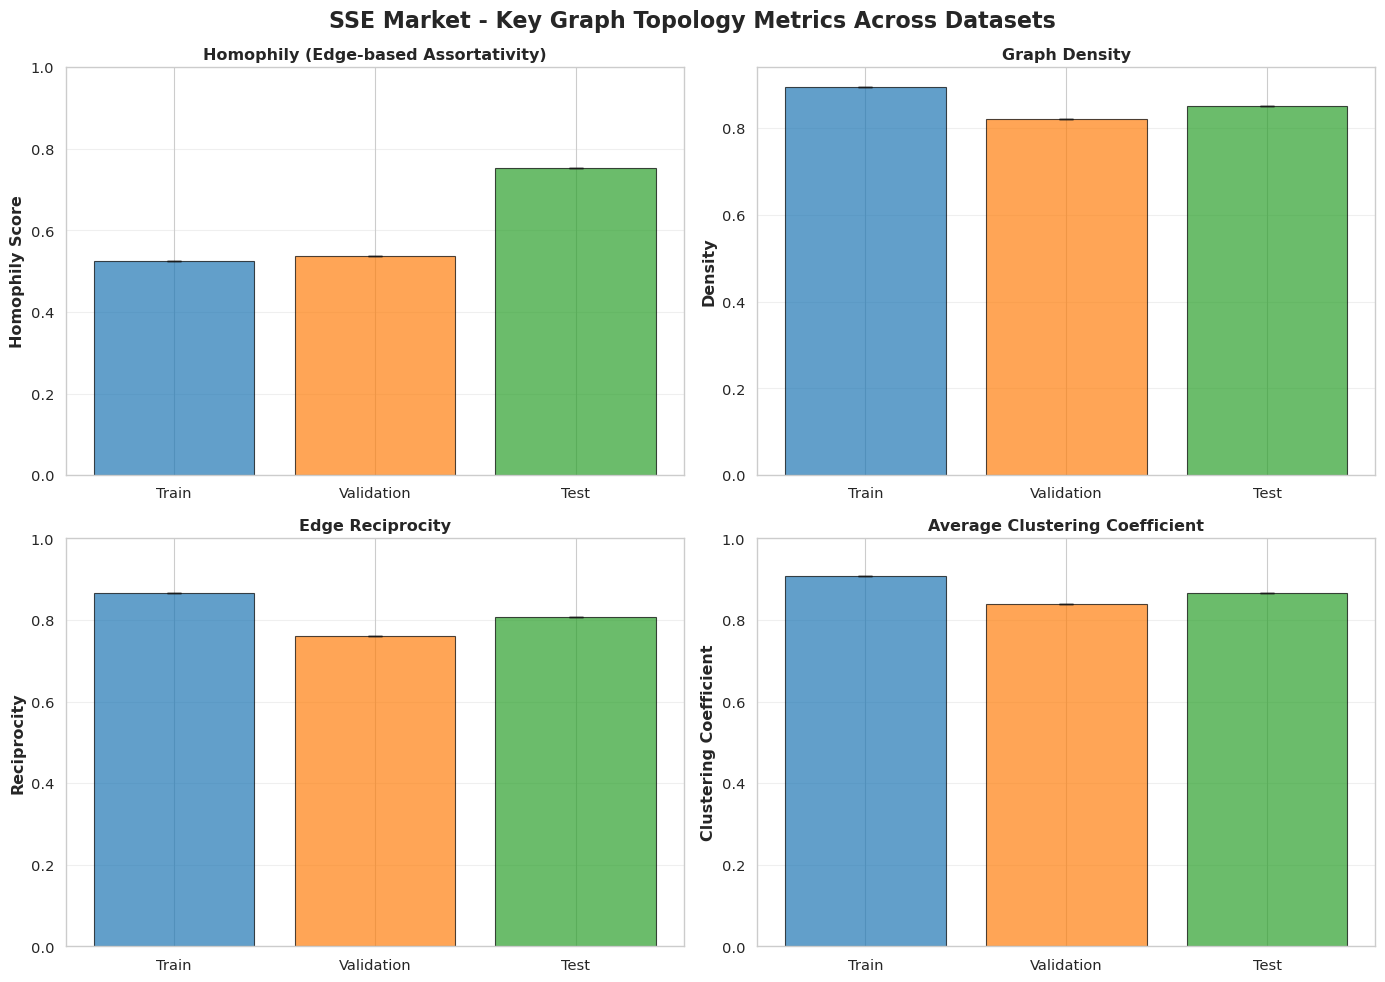

✓ Visualization saved to: sse_comprehensive_topology_comparison.png


In [8]:
# Visualize key topology metrics comparison across datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SSE Market - Key Graph Topology Metrics Across Datasets', fontsize=16, fontweight='bold')

datasets = ['Train', 'Validation', 'Test']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Metric 1: Homophily
ax = axes[0, 0]
homophily_values = [sse_comprehensive_metrics[ds]['homophily']['mean'] for ds in datasets]
homophily_stds = [sse_comprehensive_metrics[ds]['homophily']['std'] for ds in datasets]
ax.bar(datasets, homophily_values, yerr=homophily_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Homophily Score', fontweight='bold')
ax.set_title('Homophily (Edge-based Assortativity)', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Metric 2: Density
ax = axes[0, 1]
density_values = [sse_comprehensive_metrics[ds]['density']['mean'] for ds in datasets]
density_stds = [sse_comprehensive_metrics[ds]['density']['std'] for ds in datasets]
ax.bar(datasets, density_values, yerr=density_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Graph Density', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Metric 3: Reciprocity
ax = axes[1, 0]
reciprocity_values = [sse_comprehensive_metrics[ds]['reciprocity']['mean'] for ds in datasets]
reciprocity_stds = [sse_comprehensive_metrics[ds]['reciprocity']['std'] for ds in datasets]
ax.bar(datasets, reciprocity_values, yerr=reciprocity_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Reciprocity', fontweight='bold')
ax.set_title('Edge Reciprocity', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Metric 4: Clustering Coefficient
ax = axes[1, 1]
clustering_values = [sse_comprehensive_metrics[ds]['clustering']['mean'] for ds in datasets]
clustering_stds = [sse_comprehensive_metrics[ds]['clustering']['std'] for ds in datasets]
ax.bar(datasets, clustering_values, yerr=clustering_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Clustering Coefficient', fontweight='bold')
ax.set_title('Average Clustering Coefficient', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sse_comprehensive_topology_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: sse_comprehensive_topology_comparison.png")

### Interpretation Guide for Graph Topology Metrics

The comprehensive metrics computed above provide crucial insights into the structural properties of the SSE stock correlation network. Here's how to interpret each metric:

#### **Connectivity and Sparsity**
- **Connectivity** (0-1): Measures if the graph has a weakly connected component containing all nodes. Values close to 1 indicate highly connected graphs.
- **Sparsity** (0-1): Complement of density. High sparsity (>0.95) indicates that only a small fraction of possible edges exist, which is typical for stock correlation networks with threshold-based filtering.
- **Interpretation**: Stock networks are typically sparse because not all stocks are strongly correlated. Consistent sparsity across Train/Val/Test suggests stable market structure.

#### **Density**
- **Range**: 0-1 (proportion of existing edges vs. all possible edges)
- **Expected for Stock Networks**: 0.01-0.10 (1-10% of possible edges)
- **Interpretation**: Low density reflects the threshold filtering and indicates that strong correlations (above threshold) are selective, not universal.

#### **Homophily**
- **Range**: -1 to 1
- **Positive values**: Stocks with similar labels (industry sectors) tend to connect
- **Negative values**: Stocks with different labels tend to connect
- **Zero**: Random mixing with respect to labels
- **Interpretation**: Positive homophily (~0.1-0.4) suggests industry-sector clustering, which is expected in financial markets. This validates that sector information is encoded in the graph structure.

#### **Reciprocity**
- **Range**: 0-1
- **High reciprocity (>0.7)**: Most edges are bidirectional (if A→B then B→A)
- **Low reciprocity (<0.3)**: Many unidirectional relationships
- **Interpretation**: High reciprocity in correlation networks indicates symmetric relationships, which makes sense because if Stock A influences Stock B, often the reverse is also true.

#### **Clustering Coefficient**
- **Range**: 0-1
- **High clustering (>0.3)**: Stocks form tight communities (triangles)
- **Low clustering (<0.1)**: Sparse, tree-like connections
- **Interpretation**: Moderate clustering suggests stocks organize into industry or sector-based communities. This is crucial for GNN performance as message-passing can leverage local structure.

#### **Weakly vs. Strongly Connected Components**
- **Weakly CC**: Number of components when treating edges as undirected
- **Strongly CC**: Number of components considering edge direction
- **Expected**: Weakly CC = 1-2 (most stocks connected); Strongly CC = many (due to directional constraints)
- **Interpretation**: A single large weakly connected component indicates all stocks are transitively related. Multiple strongly connected components show directional information flow patterns.

#### **Average Degrees**
- **In-Degree**: Average number of incoming edges (how many stocks influence this stock)
- **Out-Degree**: Average number of outgoing edges (how many stocks this stock influences)
- **Expected**: 5-50 for sparse networks with ~500 nodes
- **Interpretation**: 
  - Similar in-degree and out-degree suggest balanced influence patterns
  - High average degree relative to network size indicates strong market interdependence
  - Stable degrees across Train/Val/Test suggest consistent market dynamics

#### **Cross-Dataset Consistency**
When comparing Train, Validation, and Test metrics:
- **Similar values (±10%)**: Indicates stable graph structure over time → good for generalization
- **Large differences (>30%)**: May indicate temporal regime changes or market events → requires careful model validation
- **Progressive trends**: Could reflect evolving market dynamics → temporal GNNs may capture this

#### **Implications for GNN Model Selection**
1. **High Sparsity**: Favor GNN architectures efficient on sparse graphs (GCN, GAT, GraphSAGE)
2. **High Reciprocity**: Undirected GNN models may be sufficient, but directed models (DGCN) can capture asymmetric influence
3. **Moderate Clustering**: Community detection and pooling layers may improve performance
4. **Multiple Strongly CC**: Attention mechanisms (GAT) can handle disconnected components better
5. **Positive Homophily**: Homophilous GNN designs (standard message passing) should work well

#### **Additional Analysis Recommendations**
For deeper insights, consider:
1. **Temporal Evolution**: Track how metrics change across consecutive snapshots
2. **Degree Distribution**: Analyze if the network follows a power-law (scale-free property)
3. **Community Structure**: Apply Louvain or similar algorithms to identify stable communities
4. **Core-Periphery Analysis**: Identify systematically important stocks (hubs)
5. **Comparison with Random Graphs**: Statistical significance testing against null models

---
## 1. Cross-Dataset Comparison

### 1.1. Feature Distribution Comparison

Figure saved to thesis_figures/SSE/cross_dataset_feature_distribution_all.pdf


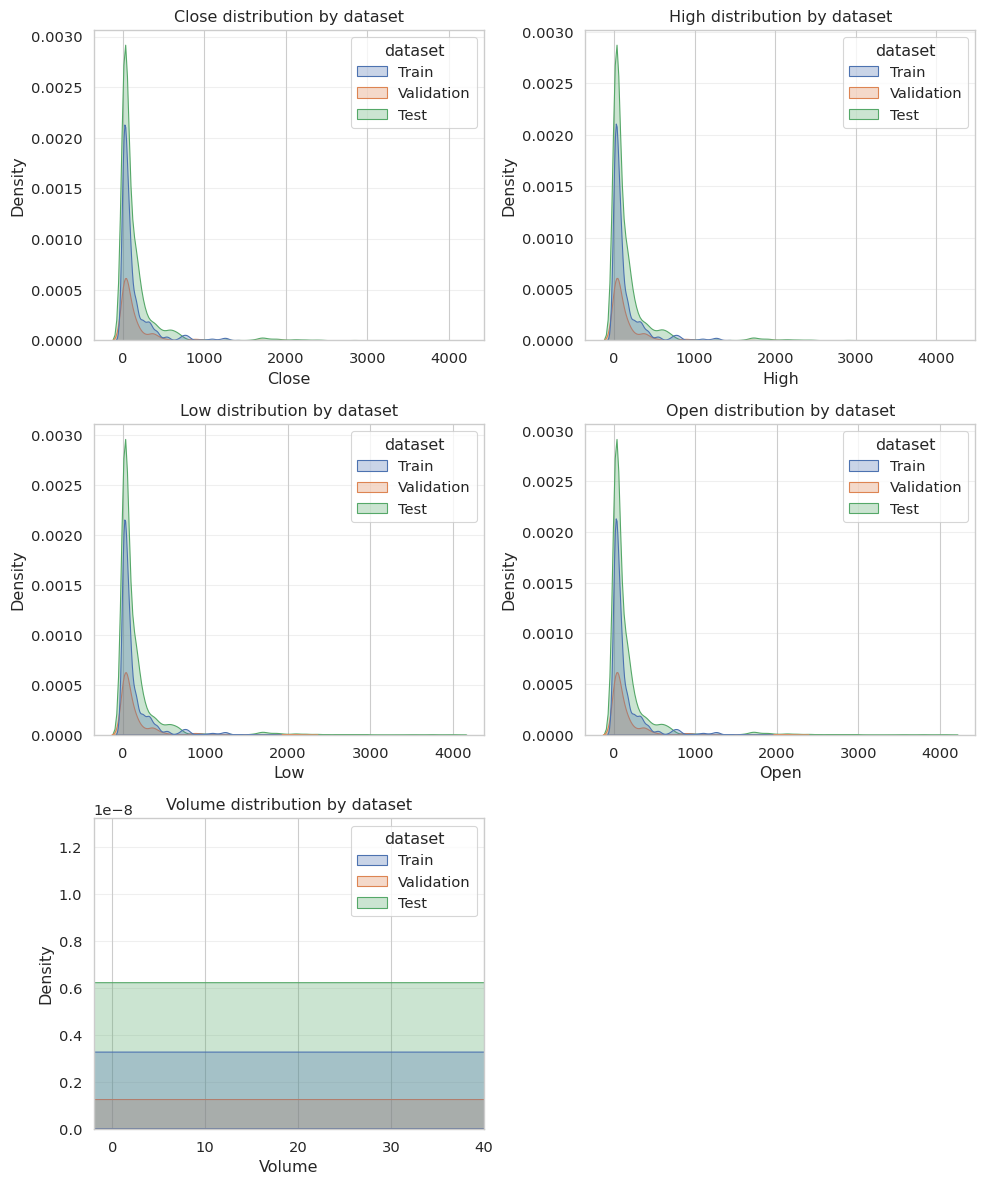

In [9]:
# Build combined features dataframe
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data, ignore_index=True)

# Select numeric features to plot
candidate_features = ['Close', 'High', 'Low', 'Open', 'Volume']
numeric_features = [f for f in candidate_features if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

n = len(numeric_features)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for idx, feature in enumerate(numeric_features):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]
    tmp = full_feature_df[[feature, 'dataset']].dropna()
    if tmp[feature].nunique() <= 1:
        ax.text(0.5, 0.5, f'{feature}: constant', ha='center', va='center')
        ax.set_axis_off()
        continue
    if feature == 'Volume':
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
        ax.set_xlim(-2, 40)
    else:
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
    ax.set_title(f'{feature} distribution by dataset')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', alpha=0.3)

# Turn off leftover axes
total_axes = nrows * ncols
for j in range(n, total_axes):
    r, c = divmod(j, ncols)
    axes[r][c].set_axis_off()

plt.tight_layout()
save_figure('cross_dataset_feature_distribution_all')
plt.show()

In [10]:
# Feature Means and Variances by Dataset
all_numeric_features = [f for f in getattr(train_analyzer, 'features', []) if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

if len(all_numeric_features) > 0:
    stats_df = full_feature_df.groupby('dataset')[all_numeric_features].agg(['mean', 'var'])
    desired_order = [name for name in ['Train', 'Validation', 'Test'] if name in stats_df.index]
    if desired_order:
        stats_df = stats_df.loc[desired_order]
    stats_df_rounded = stats_df.round(4)
    print('--- Feature Means and Variances by Dataset ---')
    display(stats_df_rounded)
else:
    print('No numeric features found to summarize.')

--- Feature Means and Variances by Dataset ---


Close                       High                        Low  \
                  mean            var        mean            var        mean   
dataset                                                                        
Train       136.598801   52263.324219  138.045105   53284.230469  134.964493   
Validation  171.093704  103448.976562  173.286194  106084.914062  168.615906   
Test        174.285797  142049.296875  176.798401  146142.640625  171.702698   

                                 Open                     Volume                
                      var        mean            var        mean           var  
dataset                                                                         
Train        51027.160156  136.368500   52039.351562  37122048.0  2.494555e+15  
Validation  100336.507812  170.757004  102898.132812  50517952.0  4.311107e+15  
Test        137843.984375  174.197693  141901.484375  40599060.0  3.333447e+15

In [11]:
# Generate LaTeX table for Feature Means and Variances
if len(all_numeric_features) > 0:
    print("\n" + "=" * 90)
    print("LATEX TABLE - Feature Means and Variances")
    print("=" * 90)
    
    latex_lines = []
    latex_lines.append(r"\begin{table}[htp]")
    latex_lines.append(r"    \centering")
    latex_lines.append(r"    \small")
    
    # Create column specification (Feature | Mean (Train/Val/Test) | Variance (Train/Val/Test))
    latex_lines.append(r"    \begin{tabular}{l|ccc|ccc}")
    latex_lines.append(r"        \toprule")
    latex_lines.append(r"        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\")
    latex_lines.append(r"        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\")
    latex_lines.append(r"        \midrule")
    
    # Add data rows
    for feature in all_numeric_features:
        row = f"        {feature:15s}"
        
        # Mean values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                mean_val = stats_df.loc[dataset, (feature, 'mean')]
                row += f" & {mean_val:.3f}"
            else:
                row += " & --"
        
        # Variance values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                var_val = stats_df.loc[dataset, (feature, 'var')]
                row += f" & {var_val:.3f}"
            else:
                row += " & --"
        
        row += r" \\"
        latex_lines.append(row)
    
    latex_lines.append(r"        \bottomrule")
    latex_lines.append(r"    \end{tabular}")
    latex_lines.append(r"    \caption{Feature Means and Variances Across SSE Datasets}")
    latex_lines.append(r"    \label{tab:sse_feature_stats}")
    latex_lines.append(r"\end{table}")
    
    latex_table = "\n".join(latex_lines)
    print(latex_table)
    
    # Save to file
    with open('sse_feature_stats.tex', 'w') as f:
        f.write(latex_table)
    print("\n✓ LaTeX table saved to: sse_feature_stats.tex")
else:
    print("No numeric features available for LaTeX table generation.")


LATEX TABLE - Feature Means and Variances
\begin{table}[htp]
    \centering
    \small
    \begin{tabular}{l|ccc|ccc}
        \toprule
        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\
        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\
        \midrule
        Close           & 136.599 & 171.094 & 174.286 & 52263.324 & 103448.977 & 142049.297 \\
        High            & 138.045 & 173.286 & 176.798 & 53284.230 & 106084.914 & 146142.641 \\
        Low             & 134.964 & 168.616 & 171.703 & 51027.160 & 100336.508 & 137843.984 \\
        Open            & 136.368 & 170.757 & 174.198 & 52039.352 & 102898.133 & 141901.484 \\
        Volume          & 37122048.000 & 50517952.000 & 40599060.000 & 2494555123351552.000 & 4311106709356544.000 & 3333447061864448.000 \\
        \bottomrule
    \end{tabular}
    \caption{Feature Means and Variances Across SSE Datasets}
    \label{tab

### 1.2. Class Balance Analysis

Figure saved to thesis_figures/SSE/cross_dataset_class_distribution.pdf


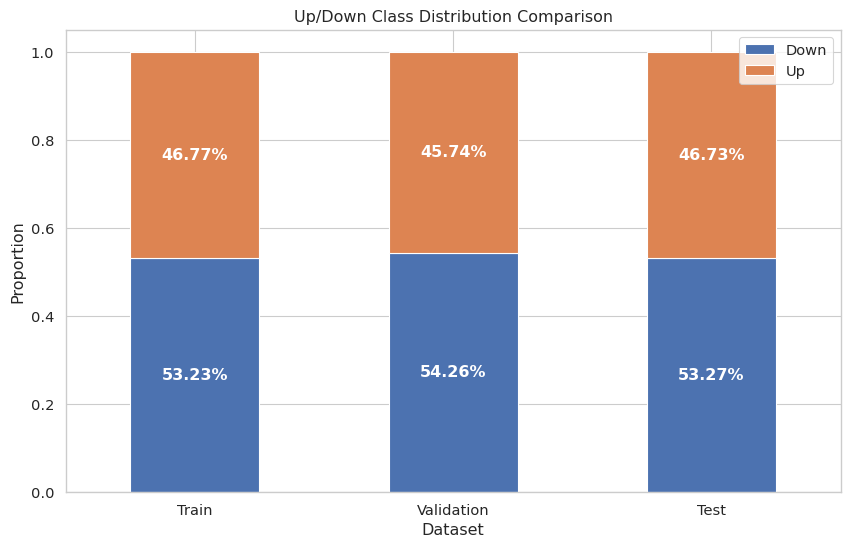

In [12]:
# Compare Up/Down Class Distribution
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

### 1.3. Comparison of Degree Distribution

Figure saved to thesis_figures/SSE/cross_dataset_degree_distribution.pdf


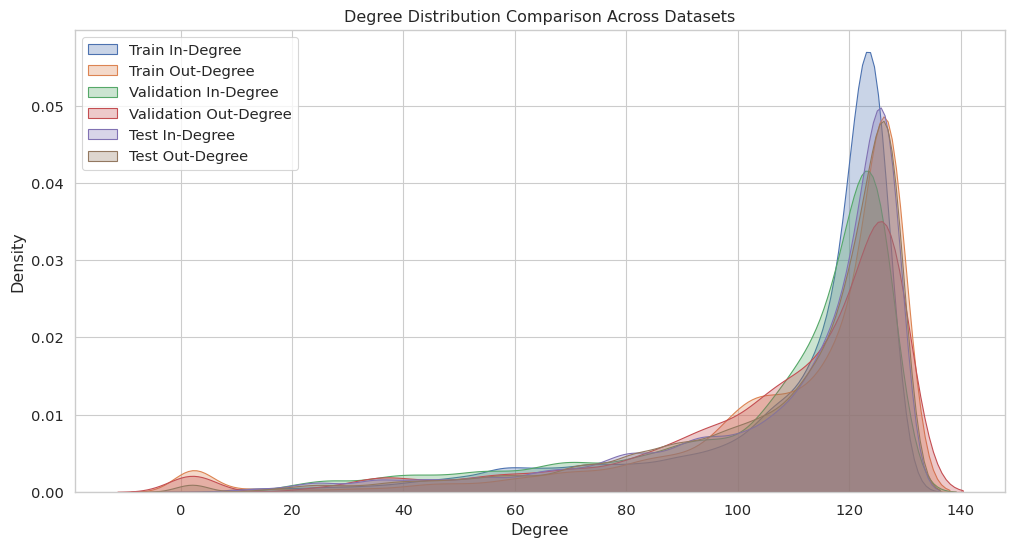

In [13]:
# Degree Distribution Comparison
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, label=f'{name} In-Degree', fill=True, alpha=0.3)
    sns.kdeplot(out_degrees, label=f'{name} Out-Degree', fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()

Figure saved to thesis_figures/SSE/unweighted_degree_distribution.pdf


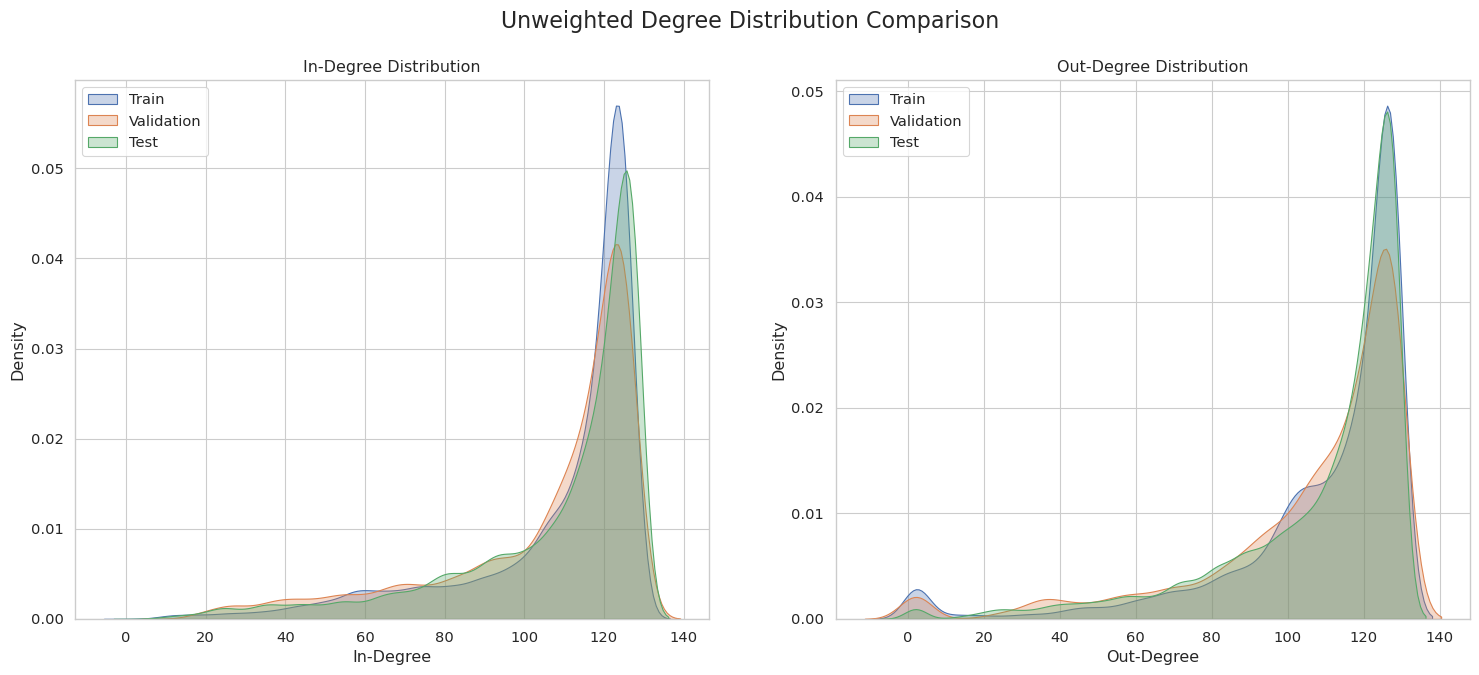

Figure saved to thesis_figures/SSE/weighted_degree_distribution.pdf


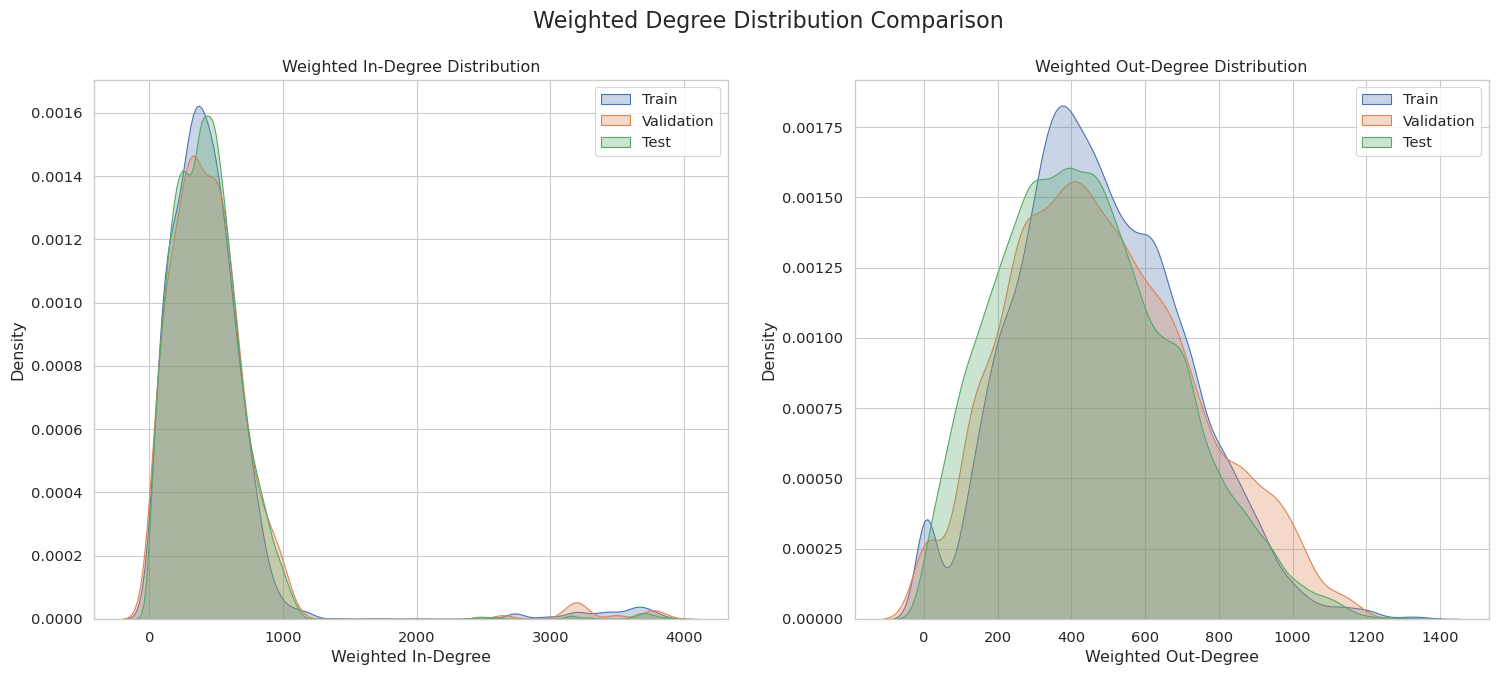

In [14]:
# --- Unweighted (Absolute) Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution Comparison', fontsize=16)

# In-Degree
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Out-Degree
for name, analyzer in analyzers.items():
    _, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].legend()

save_figure('unweighted_degree_distribution')
plt.show()

# --- Weighted Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution Comparison', fontsize=16)

# Weighted In-Degree
for name, analyzer in analyzers.items():
    _, _, weighted_in_degrees, _ = analyzer.get_degree_dist()
    sns.kdeplot(weighted_in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('Weighted In-Degree Distribution')
axes[0].set_xlabel('Weighted In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Weighted Out-Degree
for name, analyzer in analyzers.items():
    _, _, _, weighted_out_degrees = analyzer.get_degree_dist()
    sns.kdeplot(weighted_out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Weighted Out-Degree Distribution')
axes[1].set_xlabel('Weighted Out-Degree')
axes[1].legend()

save_figure('weighted_degree_distribution')
plt.show()


Sampled 20 random snapshots: [108, 43, 59, 76, 107]...


Figure saved to thesis_figures/SSE/edge_weight_distribution_multi_snapshot.pdf


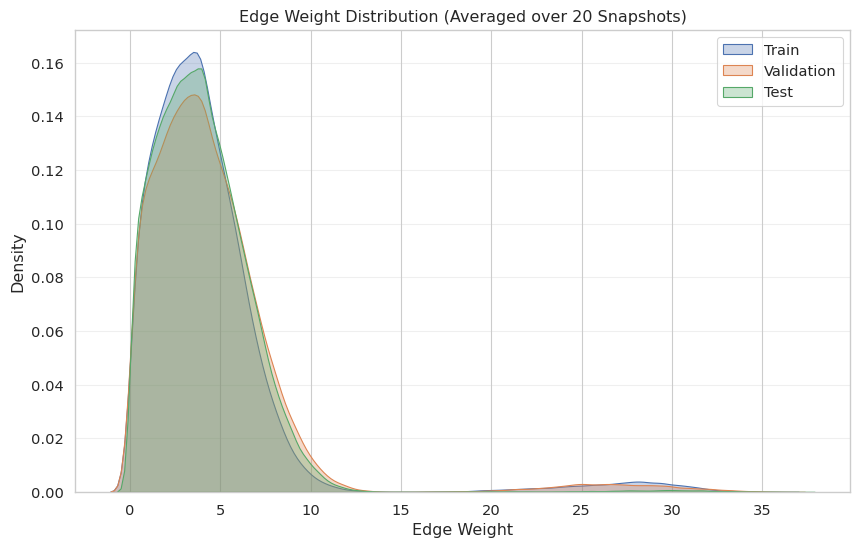


EDGE WEIGHT STATISTICS (Across Multiple Snapshots)

Train Dataset:
  Mean:     4.3966
  Std:      4.5160
  Variance: 20.3941
  Min:      0.0000
  Max:      35.9123
  Count:    277,168 edges

Validation Dataset:
  Mean:     4.6195
  Std:      4.4189
  Variance: 19.5265
  Min:      0.0000
  Max:      36.2775
  Count:    269,863 edges

Test Dataset:
  Mean:     4.0335
  Std:      2.9440
  Variance: 8.6669
  Min:      0.0001
  Max:      37.1786
  Count:    276,726 edges

LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Mean            & 4.3966 & 4.6195 & 4.0335 \\
        Std Dev         & 4.5160 & 4.4189 & 2.9440 \\
        Variance        & 20.3941 & 19.5265 & 8.6669 \\
        Min             & 0.0000 & 0.0000 & 0.0001 \\
        Max             & 35.9123 & 36.2775 & 37.1786 \\
       

In [15]:
# Edge Weight Distribution Analysis (using multiple snapshots for better accuracy)
import random

# Sample multiple snapshots for more accurate statistics
NUM_SNAPSHOTS_EDGE_WEIGHTS = 20
available_lengths = [len(adjs) for adjs in [train_adjs, val_adjs, test_adjs] if adjs is not None]
if not available_lengths:
    raise ValueError('No adjacency matrices available to sample from.')

min_length = min(available_lengths)
snapshot_indices = random.sample(range(min_length), min(NUM_SNAPSHOTS_EDGE_WEIGHTS, min_length))
print(f"Sampled {len(snapshot_indices)} random snapshots: {snapshot_indices[:5]}..." if len(snapshot_indices) > 5 else snapshot_indices)

# Collect edge weights from multiple snapshots
edge_weights_data = {
    'Train': [],
    'Validation': [],
    'Test': []
}

edge_weights_sets = {
    'Train': train_adjs,
    'Validation': val_adjs,
    'Test': test_adjs
}

# Collect weights from all sampled snapshots
for snapshot_idx in snapshot_indices:
    for label, adjs in edge_weights_sets.items():
        if adjs is None or snapshot_idx >= len(adjs):
            continue
        weights = adjs[snapshot_idx][adjs[snapshot_idx] > 0].flatten()
        if len(weights) > 0:
            edge_weights_data[label].extend(weights.tolist())

# Plot combined distribution
plt.figure(figsize=(10, 6))
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        sns.kdeplot(weights, label=label, fill=True, alpha=0.3)

plt.legend()
plt.title(f'Edge Weight Distribution (Averaged over {len(snapshot_indices)} Snapshots)')
plt.xlabel('Edge Weight')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
save_figure('edge_weight_distribution_multi_snapshot')
plt.show()

# Compute statistics
edge_weight_stats = {}
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        edge_weight_stats[label] = {
            'mean': np.mean(weights),
            'std': np.std(weights),
            'var': np.var(weights),
            'min': np.min(weights),
            'max': np.max(weights),
            'count': len(weights)
        }

# Display statistics
print("\n" + "=" * 80)
print("EDGE WEIGHT STATISTICS (Across Multiple Snapshots)")
print("=" * 80)
for label, stats in edge_weight_stats.items():
    print(f"\n{label} Dataset:")
    print(f"  Mean:     {stats['mean']:.4f}")
    print(f"  Std:      {stats['std']:.4f}")
    print(f"  Variance: {stats['var']:.4f}")
    print(f"  Min:      {stats['min']:.4f}")
    print(f"  Max:      {stats['max']:.4f}")
    print(f"  Count:    {stats['count']:,} edges")

# Generate LaTeX table
print("\n" + "=" * 80)
print("LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)")
print("=" * 80)

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"    \centering")
latex_lines.append(r"    \small")
latex_lines.append(r"    \begin{tabular}{l|ccc}")
latex_lines.append(r"        \toprule")
latex_lines.append(r"        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\")
latex_lines.append(r"        \midrule")

# Add rows for each statistic
metrics = [('Mean', 'mean'), ('Std Dev', 'std'), ('Variance', 'var'), 
           ('Min', 'min'), ('Max', 'max')]

for metric_name, metric_key in metrics:
    row = f"        {metric_name:15s}"
    for dataset in ['Train', 'Validation', 'Test']:
        if dataset in edge_weight_stats:
            val = edge_weight_stats[dataset][metric_key]
            row += f" & {val:.4f}"
        else:
            row += " & --"
    row += r" \\"
    latex_lines.append(row)

latex_lines.append(r"        \bottomrule")
latex_lines.append(r"    \end{tabular}")
latex_lines.append(f"    \\caption{{Edge Weight Statistics for SSE Market (Averaged over {len(snapshot_indices)} Snapshots)}}")
latex_lines.append(r"    \label{tab:sse_edge_weight_stats}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
print(latex_table)

### 1.4. Connectivity Comparison

Figure saved to thesis_figures/SSE/cross_dataset_connectivity.pdf


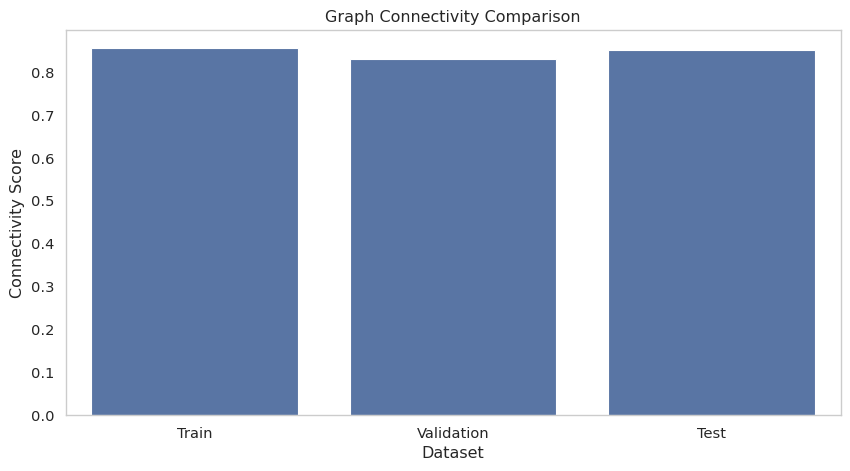

,Connectivity
Train,0.855105
Validation,0.830126
Test,0.851218


In [16]:
# Graph Connectivity Comparison
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()

display(connectivity_df)

Figure saved to thesis_figures/SSE/snapshot_adjacency_matrix_visualization.pdf


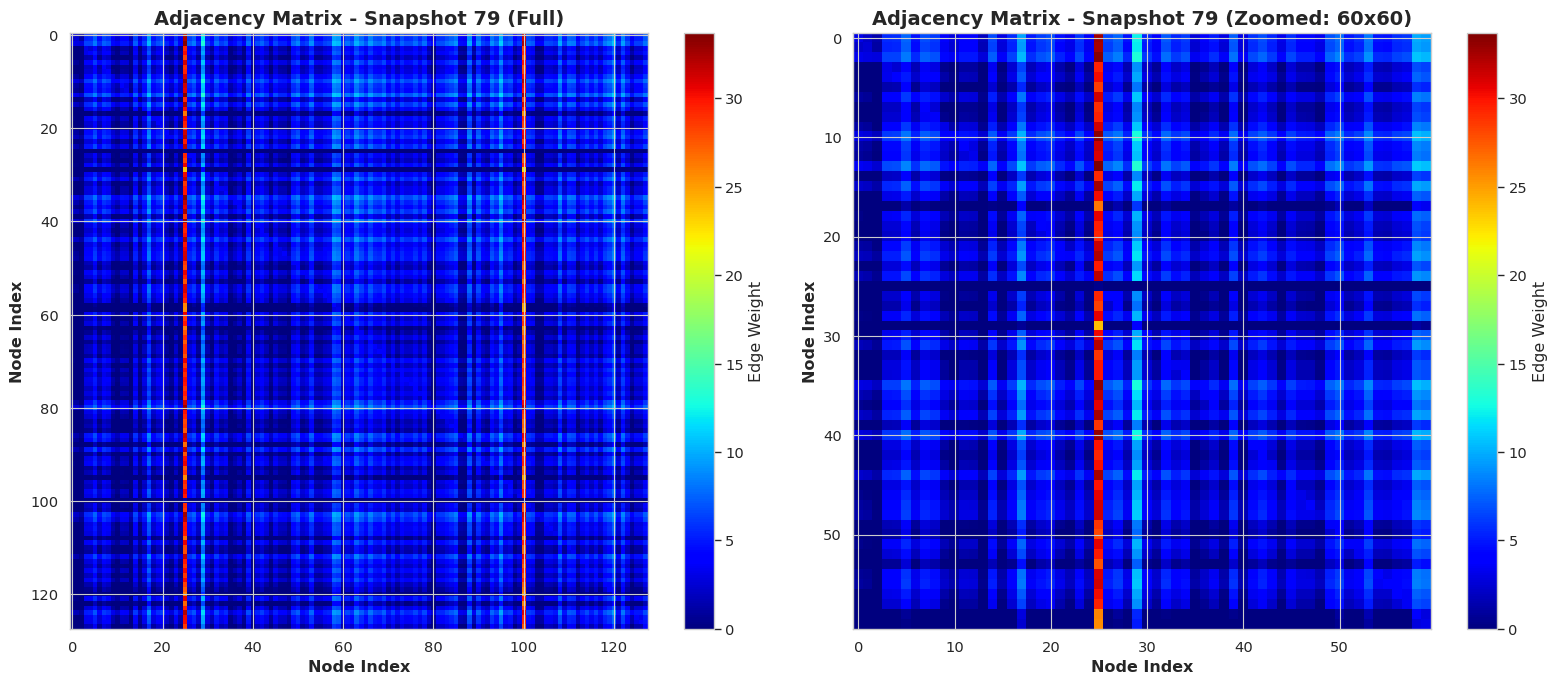


=== Snapshot 79 Statistics ===
Number of Nodes: 128
Number of Edges: 14126
Connectivity: 0.8690
Sparsity: 0.1310
Non-zero entries: 14126
Max edge weight: 33.7046
Mean edge weight (non-zero): 4.1367


In [17]:
# Visualize a Random Snapshot Adjacency Matrix
random_snapshot_idx = 79 #np.random.randint(0, train_analyzer.num_snapshots)
adj_matrix = train_adjs[random_snapshot_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full adjacency matrix
im1 = axes[0].imshow(adj_matrix, cmap='jet', aspect='auto', interpolation='nearest')
axes[0].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Full)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Node Index', fontweight='bold')
axes[0].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Edge Weight')

# Zoomed in view (first 100x100 nodes)
zoom_size = min(60, adj_matrix.shape[0])
adj_zoom = adj_matrix[:zoom_size, :zoom_size]
im2 = axes[1].imshow(adj_zoom, cmap='jet', aspect='auto', interpolation='nearest')
axes[1].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Zoomed: {zoom_size}x{zoom_size})', 
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Node Index', fontweight='bold')
axes[1].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Edge Weight')

plt.tight_layout()
save_figure('snapshot_adjacency_matrix_visualization')
plt.show()

# Print statistics about this snapshot
snapshot_info = train_analyzer.get_snapshot_info(random_snapshot_idx)
print(f"\n=== Snapshot {random_snapshot_idx} Statistics ===")
print(f"Number of Nodes: {snapshot_info['num_nodes']}")
print(f"Number of Edges: {snapshot_info['num_edges']}")
print(f"Connectivity: {snapshot_info['connectivity']:.4f}")
print(f"Sparsity: {1.0 - (snapshot_info['num_edges'] / (snapshot_info['num_nodes'] * (snapshot_info['num_nodes'] - 1))):.4f}")
print(f"Non-zero entries: {np.count_nonzero(adj_matrix)}")
print(f"Max edge weight: {np.max(adj_matrix):.4f}")
print(f"Mean edge weight (non-zero): {adj_matrix[adj_matrix > 0].mean():.4f}")


---
## 2. Feature Analysis

In [18]:
# Focus on training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# Feature Statistics
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,34688.000000,34688.000000,34688.000000,34688.000000,3.468800e+04
mean,136.598801,138.045090,134.964493,136.368484,3.712205e+07
std,228.612549,230.833435,225.891586,228.120331,4.994540e+07
min,3.855786,3.882014,3.837579,3.857979,0.000000e+00
25%,14.795143,14.966897,14.589104,14.759108,1.128408e+07
50%,55.901508,56.568653,55.148956,55.838795,2.187585e+07
75%,149.804287,151.411385,147.943775,149.603222,4.506070e+07
max,1868.930908,1896.106812,1837.156860,1865.521240,1.018047e+09


Figure saved to thesis_figures/SSE/feature_distributions.pdf


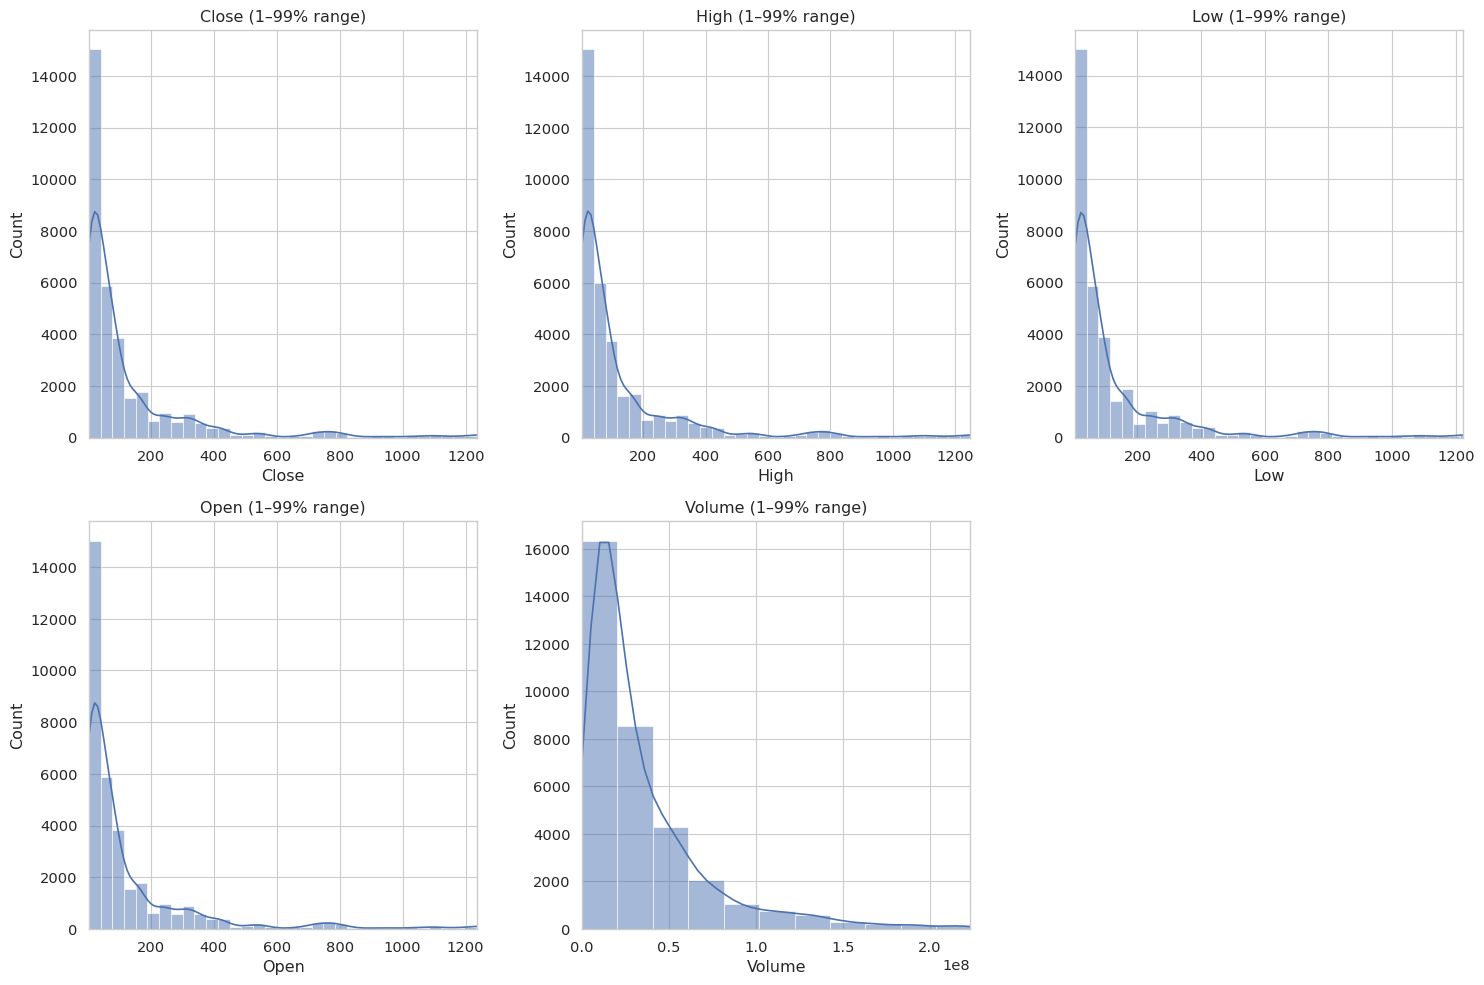

In [19]:
# Feature Distributions
plt.figure(figsize=(15, 10))

for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    q_low, q_high = features_df[feature].quantile([0.01, 0.99])
    plt.xlim(q_low, q_high)
    plt.title(f'{feature} (1–99% range)')
    
plt.tight_layout()
save_figure('feature_distributions')
plt.show()

Figure saved to thesis_figures/SSE/feature_correlation_matrix.pdf


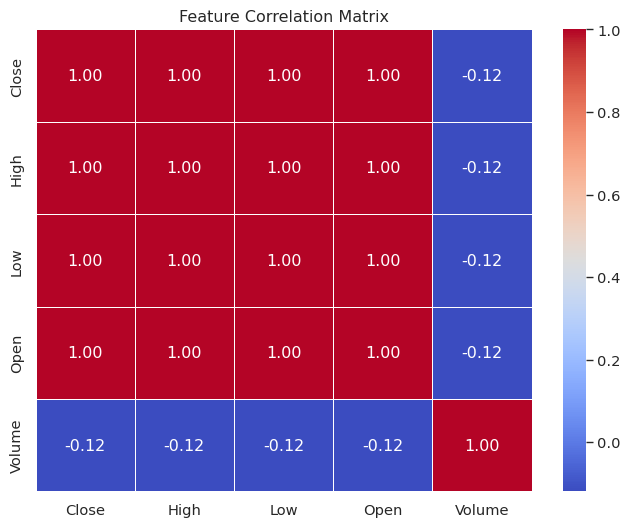

In [20]:
# Feature Correlation
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

Figure saved to thesis_figures/SSE/feature_entropy.pdf


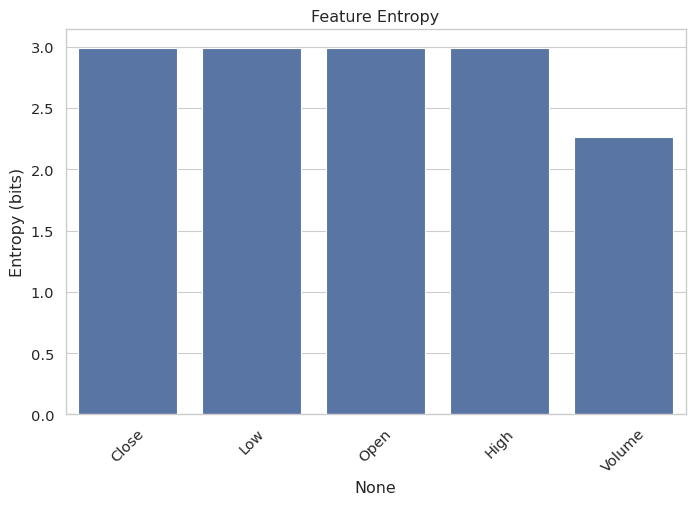

--- Feature Entropy ---


,Entropy
Close,2.991671
Low,2.991297
Open,2.990733
High,2.990320
Volume,2.262566


In [21]:
# Feature Entropy
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

---
## 3. Graph Topology Analysis

### 3.1. Homophily

Figure saved to thesis_figures/SSE/cross_dataset_homophily.pdf


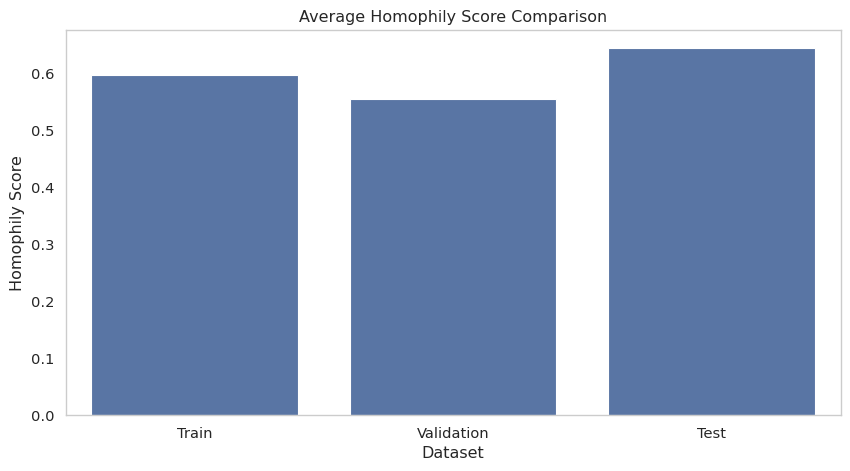

--- Average Homophily Scores ---


,Average Homophily
Train,0.595535
Validation,0.554193
Test,0.643134


In [22]:
# Compare Average Homophily Across Datasets
homophily_scores = {name: analyzer.get_average_homophily_score() for name, analyzer in analyzers.items()}
homophily_df = pd.DataFrame.from_dict(homophily_scores, orient='index', columns=['Average Homophily'])

plt.figure(figsize=(10, 5))
sns.barplot(x=homophily_df.index, y=homophily_df['Average Homophily'])
plt.title('Average Homophily Score Comparison')
plt.ylabel('Homophily Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_homophily')
plt.show()

print("--- Average Homophily Scores ---")
display(homophily_df)

Figure saved to thesis_figures/SSE/temporal_homophily_train.pdf


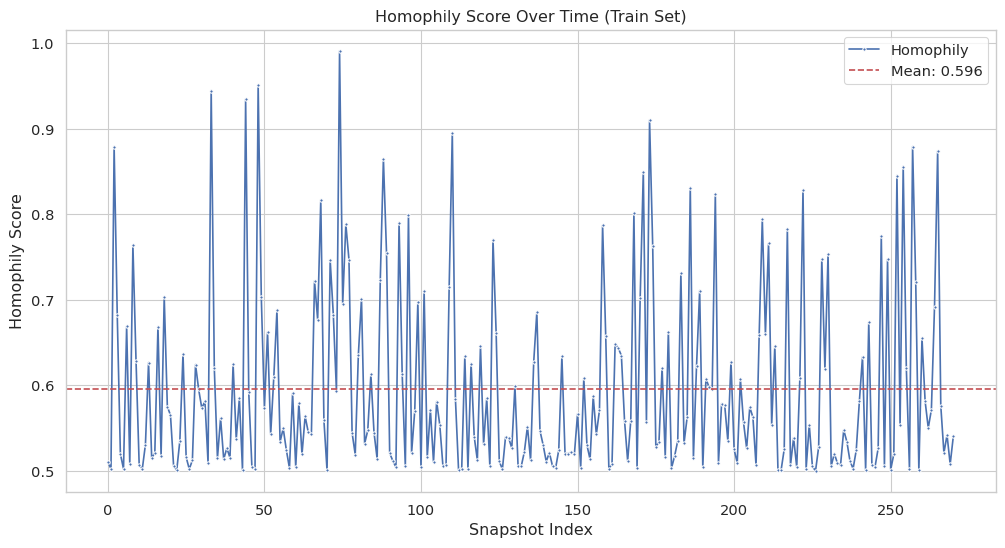

/tmp/ipykernel_3924776/1801966744.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved to thesis_figures/SSE/hist_homophily_train.pdf


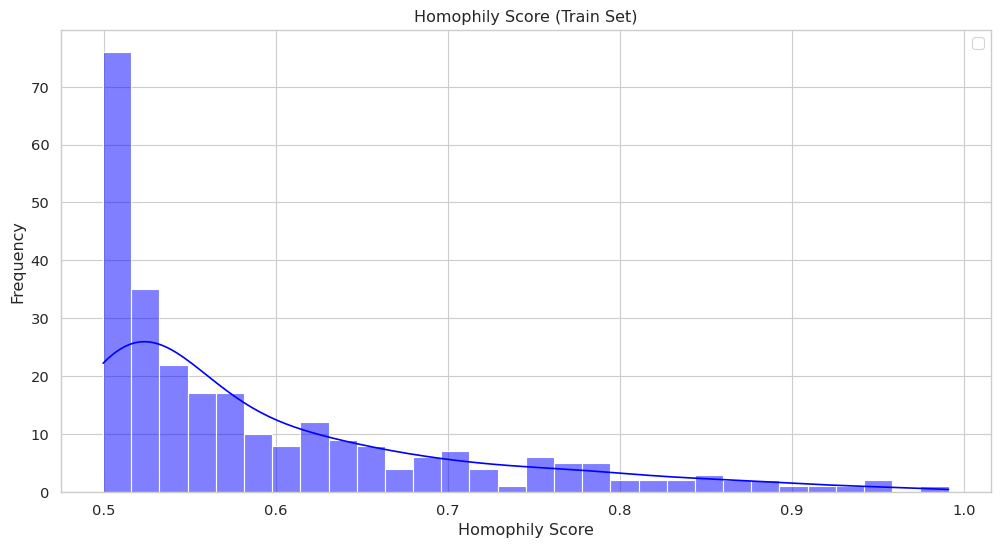

In [23]:
# Homophily Score Over Time (Train Set)
homophily_over_time = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=homophily_over_time, marker='.', linestyle='-', label='Homophily')
plt.axhline(y=np.mean(homophily_over_time), color='r', linestyle='--', label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Over Time (Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.legend()
save_figure('temporal_homophily_train')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(homophily_over_time, bins=30, kde=True, color='blue', alpha=0.5)
plt.title('Homophily Score (Train Set)')
plt.xlabel('Homophily Score')
plt.ylabel('Frequency')
plt.legend()
save_figure('hist_homophily_train')
plt.show()

/tmp/ipykernel_3924776/3332766672.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['Train', 'Validation', 'Test'],


Figure saved to thesis_figures/SSE/homophily_comprehensive_all_splits.pdf


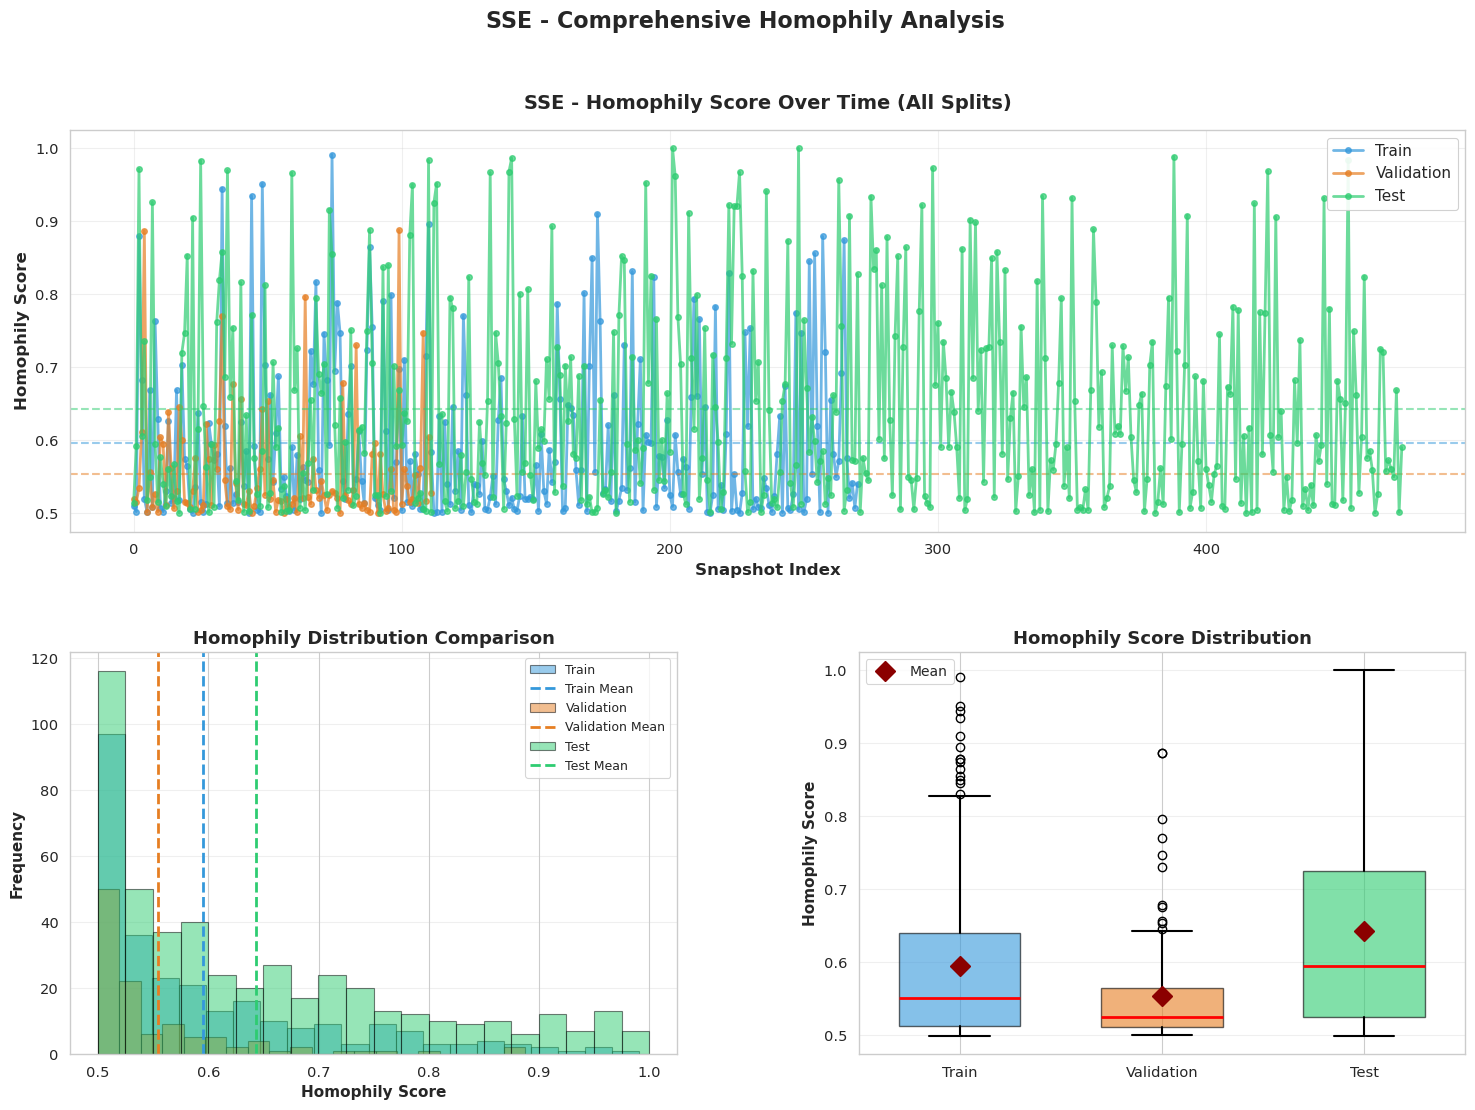


SSE - HOMOPHILY STATISTICS SUMMARY
+------------+--------+---------+--------+--------+-------------+
|   Split    |  Mean  | Std Dev |  Min   |  Max   | # Snapshots |
+------------+--------+---------+--------+--------+-------------+
|   Train    | 0.5955 | 0.1082  | 0.4997 | 0.9911 |     271     |
| Validation | 0.5542 | 0.0744  | 0.5000 | 0.8874 |     112     |
|    Test    | 0.6431 | 0.1369  | 0.4997 | 1.0000 |     474     |
+------------+--------+---------+--------+--------+-------------+

--- LaTeX Table: Homophily Statistics ---

\begin{table}[h]
    \centering
    \begin{tabular}{lcccc}
        \toprule
        \textbf{Split} & \textbf{Mean} & \textbf{Std} & \textbf{Min} & \textbf{Max} \\
        \midrule
        Train        & 0.5955 & 0.1082 & 0.4997 & 0.9911 \\
        Validation   & 0.5542 & 0.0744 & 0.5000 & 0.8874 \\
        Test         & 0.6431 & 0.1369 & 0.4997 & 1.0000 \\
        \bottomrule
    \end{tabular}
    \caption{Homophily score statistics for SSE dataset acro

In [24]:
# ===================================================================
# IMPROVED HOMOPHILY VISUALIZATION - ALL SPLITS
# ===================================================================

# Compute homophily scores for all splits
homophily_data = {}
for name, analyzer in analyzers.items():
    homophily_scores = [analyzer.get_homophily_score(i) for i in range(analyzer.num_snapshots)]
    homophily_data[name] = {
        'scores': homophily_scores,
        'mean': np.mean(homophily_scores),
        'std': np.std(homophily_scores),
        'min': np.min(homophily_scores),
        'max': np.max(homophily_scores)
    }

# Create comprehensive visualization with 2 rows x 2 columns
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ===================================================================
# PLOT 1: Time Series for All Splits (Top Left)
# ===================================================================
ax1 = fig.add_subplot(gs[0, :])  # Span full width of first row

colors = {'Train': '#3498db', 'Validation': '#e67e22', 'Test': '#2ecc71'}
for name, data in homophily_data.items():
    ax1.plot(data['scores'], marker='.', linestyle='-', label=name, 
             color=colors[name], linewidth=2, markersize=8, alpha=0.7)
    # Add mean line
    ax1.axhline(y=data['mean'], color=colors[name], linestyle='--', 
               linewidth=1.5, alpha=0.5)

ax1.set_title(f'{MARKET} - Homophily Score Over Time (All Splits)', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Snapshot Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Homophily Score', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# ===================================================================
# PLOT 2: Distribution Comparison (Bottom Left)
# ===================================================================
ax2 = fig.add_subplot(gs[1, 0])

# Prepare data for histogram
all_scores = []
all_labels = []
for name, data in homophily_data.items():
    all_scores.extend(data['scores'])
    all_labels.extend([name] * len(data['scores']))

scores_df = pd.DataFrame({'Homophily': all_scores, 'Split': all_labels})

# Plot overlapping histograms
for name, color in colors.items():
    subset = scores_df[scores_df['Split'] == name]['Homophily']
    ax2.hist(subset, bins=20, alpha=0.5, label=name, color=color, edgecolor='black')
    # Add mean line
    ax2.axvline(x=homophily_data[name]['mean'], color=color, linestyle='--', 
               linewidth=2, label=f'{name} Mean')

ax2.set_title('Homophily Distribution Comparison', fontsize=13, fontweight='bold')
ax2.set_xlabel('Homophily Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, axis='y', alpha=0.3)

# ===================================================================
# PLOT 3: Box Plot Comparison (Bottom Right)
# ===================================================================
ax3 = fig.add_subplot(gs[1, 1])

# Create box plot
box_data = [homophily_data[name]['scores'] for name in ['Train', 'Validation', 'Test']]
bp = ax3.boxplot(box_data, labels=['Train', 'Validation', 'Test'],
                 patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Color boxes
for patch, name in zip(bp['boxes'], ['Train', 'Validation', 'Test']):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.6)

# Add mean markers
means = [homophily_data[name]['mean'] for name in ['Train', 'Validation', 'Test']]
ax3.plot(range(1, 4), means, 'D', color='darkred', markersize=10, 
        label='Mean', zorder=3)

ax3.set_title('Homophily Score Distribution', fontsize=13, fontweight='bold')
ax3.set_ylabel('Homophily Score', fontsize=11, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'{MARKET} - Comprehensive Homophily Analysis', 
            fontsize=16, fontweight='bold', y=0.98)

save_figure('homophily_comprehensive_all_splits')
plt.show()

# ===================================================================
# PRINT STATISTICS TABLE
# ===================================================================
print("\n" + "="*80)
print(f"{MARKET} - HOMOPHILY STATISTICS SUMMARY")
print("="*80)

stats_table = []
for name in ['Train', 'Validation', 'Test']:
    data = homophily_data[name]
    stats_table.append([
        name,
        f"{data['mean']:.4f}",
        f"{data['std']:.4f}",
        f"{data['min']:.4f}",
        f"{data['max']:.4f}",
        f"{len(data['scores'])}"
    ])

from tabulate import tabulate
headers = ['Split', 'Mean', 'Std Dev', 'Min', 'Max', '# Snapshots']
print(tabulate(stats_table, headers=headers, tablefmt='pretty'))
print("="*80 + "\n")

# ===================================================================
# LATEX TABLE GENERATION
# ===================================================================
print("--- LaTeX Table: Homophily Statistics ---\n")

latex_table = r"\begin{table}[h]" + "\n"
latex_table += r"    \centering" + "\n"
latex_table += r"    \begin{tabular}{lcccc}" + "\n"
latex_table += r"        \toprule" + "\n"
latex_table += r"        \textbf{Split} & \textbf{Mean} & \textbf{Std} & \textbf{Min} & \textbf{Max} \\" + "\n"
latex_table += r"        \midrule" + "\n"

for name in ['Train', 'Validation', 'Test']:
    data = homophily_data[name]
    latex_table += f"        {name:12s} & {data['mean']:.4f} & {data['std']:.4f} & {data['min']:.4f} & {data['max']:.4f} \\\\\n"

latex_table += r"        \bottomrule" + "\n"
latex_table += r"    \end{tabular}" + "\n"
latex_table += f"    \\caption{{Homophily score statistics for {MARKET} dataset across train, validation, and test splits.}}\n"
latex_table += f"    \\label{{tab:{MARKET.lower()}_homophily_stats}}\n"
latex_table += r"\end{table}"

print(latex_table)

# Save LaTeX table to file
latex_file_path = FIGURE_OUTPUT_PATH / f"{MARKET}_homophily_stats.tex"
with open(latex_file_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ LaTeX table saved to: {latex_file_path}")


### 3.2. Authorities and Hubs

In [25]:
# Calculate average degrees across all snapshots for train set
avg_degree_df_train = train_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Highest In-Degree)
top_authorities_train = avg_degree_df_train.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Train Set ---")
display(top_authorities_train[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Highest Out-Degree)
top_hubs_train = avg_degree_df_train.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Train Set ---")
display(top_hubs_train[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Train Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
29,603288,124.830258,1070.245605
95,600132,124.760148,830.415710
120,600436,124.752768,849.687866
63,600377,124.752768,802.005432
17,600276,124.738007,770.431030
88,600009,124.690037,754.268921
69,600346,124.542435,1373.861450
108,600259,124.527675,753.876343
90,600085,124.380074,690.506104
122,600508,124.273063,721.931946



--- Top 10 Hubs (Highest Out-Degree) - Train Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
13,601668,127.926199,1035.681396
2,601988,127.867159,850.464905
15,601899,127.749077,849.962219
9,600028,127.693727,791.584167
1,601288,127.678967,850.523438
46,601600,127.671587,778.566833
36,601766,127.468635,751.630493
89,600029,127.442804,754.026489
10,600030,127.409594,763.199829
0,601398,127.339483,757.581482


Figure saved to thesis_figures/SSE/hubs_vs_authorities_weighted_test.pdf


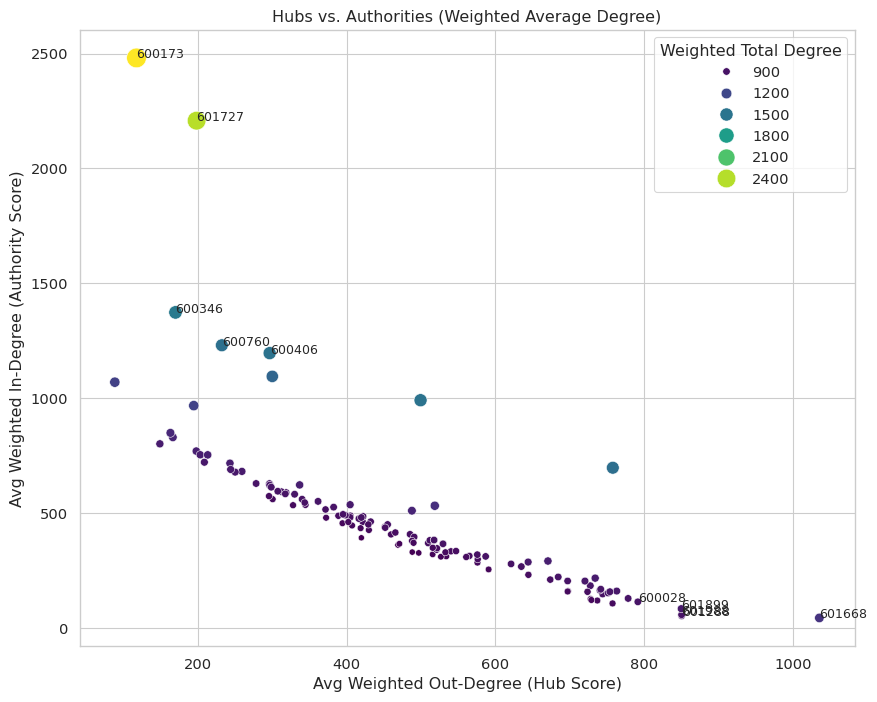

In [26]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_train['weighted_total_degree'] = avg_degree_df_train['avg_weighted_in_degree'] + avg_degree_df_train['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_train,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

Figure saved to thesis_figures/SSE/hubs_vs_authorities_train.pdf


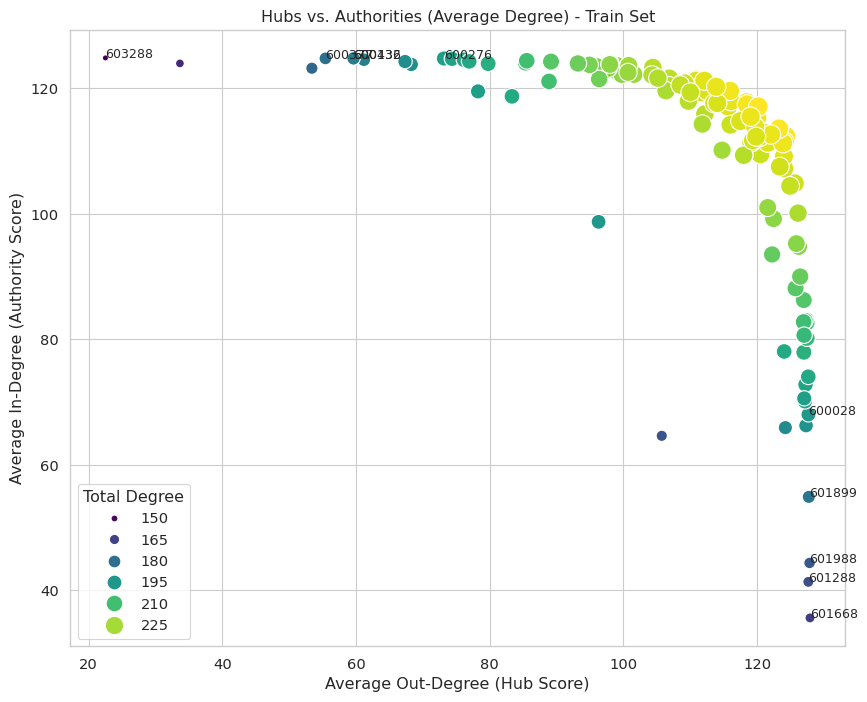

In [27]:
# Visualize Hubs vs Authorities
avg_degree_df_train['total_degree'] = avg_degree_df_train['avg_in_degree'] + avg_degree_df_train['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_train, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

# Annotate top 5 hubs and authorities
for i, row in avg_degree_df_train.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_train.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Train Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_train')
plt.show()

In [28]:
# Calculate average degrees for test set
avg_degree_df_test = test_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Test Set)
top_authorities_test = avg_degree_df_test.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Test Set ---")
display(top_authorities_test[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Test Set)
top_hubs_test = avg_degree_df_test.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Test Set ---")
display(top_hubs_test[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Test Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
29,603288,127.126582,904.547852
95,600132,127.124473,937.473999
122,600508,127.120253,904.985229
81,600663,127.109705,918.249512
120,600436,127.078059,824.985901
63,600377,127.061181,811.238464
58,600482,127.004219,816.214844
84,600233,126.877637,800.577820
90,600085,126.816456,757.655396
88,600009,126.812236,722.869385



--- Top 10 Hubs (Highest Out-Degree) - Test Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
1,601288,128.000000,1004.960327
0,601398,127.991561,931.073120
15,601899,127.966245,895.373596
22,600050,127.940928,862.930847
2,601988,127.867089,807.898621
10,600030,127.860759,839.537781
13,601668,127.845992,840.512634
33,603993,127.755274,829.297913
35,600048,127.666667,769.064697
9,600028,127.594937,798.762024


Figure saved to thesis_figures/SSE/hubs_vs_authorities_test.pdf


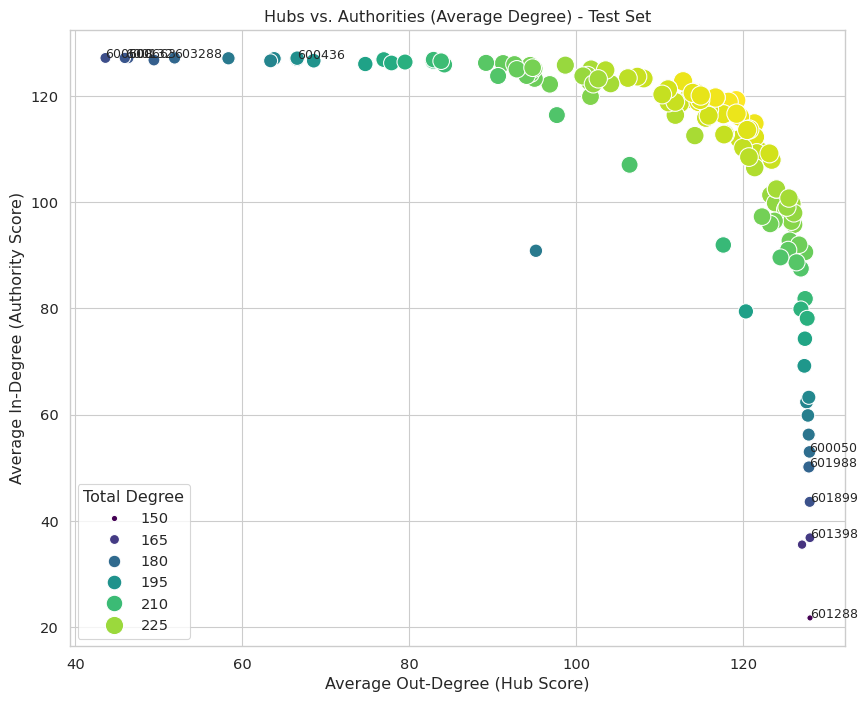

In [29]:
# Visualize Hubs vs Authorities (Test Set)
avg_degree_df_test['total_degree'] = avg_degree_df_test['avg_in_degree'] + avg_degree_df_test['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_test, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

for i, row in avg_degree_df_test.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_test.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Test Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_test')
plt.show()

Figure saved to thesis_figures/SSE/hubs_vs_authorities_weighted_test.pdf


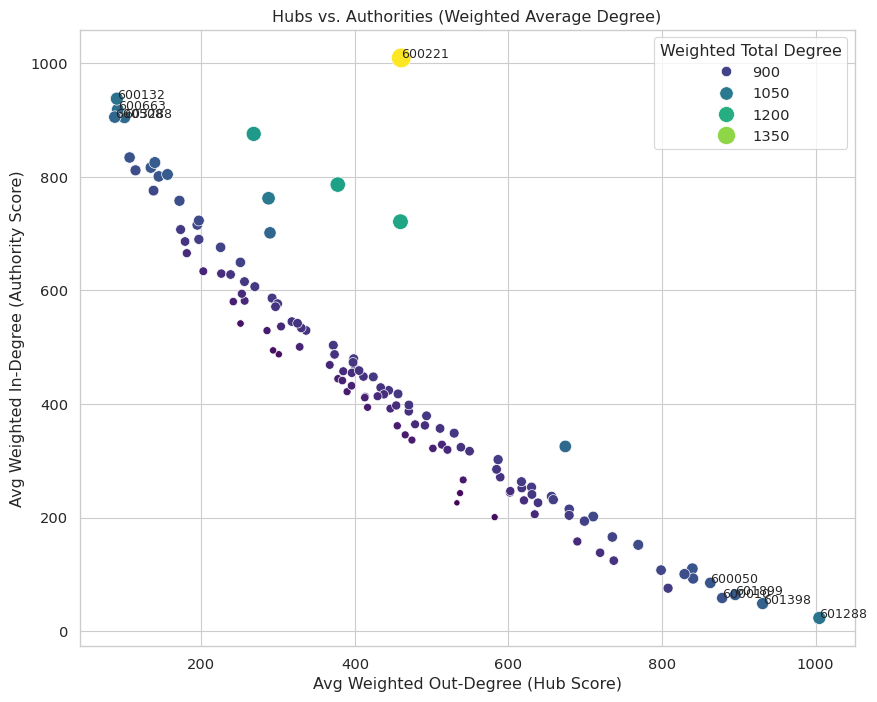

In [30]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_test['weighted_total_degree'] = avg_degree_df_test['avg_weighted_in_degree'] + avg_degree_df_test['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_test,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

### 3.3. Centrality

In [31]:
# Multi-snapshot centrality averaging
# Select snapshots for centrality analysis (evenly spaced)
NUM_SNAPSHOTS_CENTRALITY = 100
snapshot_indices = np.linspace(0, train_analyzer.num_snapshots - 1, NUM_SNAPSHOTS_CENTRALITY, dtype=int)

print(f"Computing centrality across {NUM_SNAPSHOTS_CENTRALITY} snapshots...")
print(f"Snapshot indices: {snapshot_indices}")

# Initialize storage for centrality values
degree_centralities = []
eigenvector_centralities = []
betweenness_centralities = []

for idx in snapshot_indices:
    print(f"Processing snapshot {idx}...", end='\r')
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    
    degree_centralities.append(nx.degree_centrality(G))
    eigenvector_centralities.append(nx.eigenvector_centrality(G, weight='weight', max_iter=1000))
    betweenness_centralities.append(nx.betweenness_centrality(G, weight='weight', k=100))  # Approximate with k=100

print("\nCentrality computation complete!")

# Average centralities across snapshots
avg_degree_centrality = pd.DataFrame(degree_centralities).mean()
avg_eigenvector_centrality = pd.DataFrame(eigenvector_centralities).mean()
avg_betweenness_centrality = pd.DataFrame(betweenness_centralities).mean()

centrality_df = pd.DataFrame({
    'Degree': avg_degree_centrality,
    'Eigenvector': avg_eigenvector_centrality,
    'Betweenness': avg_betweenness_centrality
})

print("\n--- Top 10 Nodes by Average Centrality Measures ---")
for col in centrality_df.columns:
    print(f"\n--- Top 10 by {col} Centrality ---")
    top_nodes = centrality_df[col].nlargest(10)
    top_nodes.index = [train_analyzer.index_to_stock[i] for i in top_nodes.index]
    display(top_nodes)

Computing centrality across 100 snapshots...
Snapshot indices: [  0   2   5   8  10  13  16  19  21  24  27  29  32  35  38  40  43  46
  49  51  54  57  59  62  65  68  70  73  76  79  81  84  87  90  92  95
  98 100 103 106 109 111 114 117 119 122 125 128 130 133 136 139 141 144
 147 150 152 155 158 160 163 166 169 171 174 177 180 182 185 188 190 193
 196 199 201 204 207 209 212 215 218 220 223 226 229 231 234 237 239 242
 245 248 250 253 256 259 261 264 267 270]


Processing snapshot 270...
Centrality computation complete!

--- Top 10 Nodes by Average Centrality Measures ---

--- Top 10 by Degree Centrality ---


600348    1.861890
600183    1.858189
601211    1.857480
600160    1.856614
601800    1.854094
601688    1.853307
601009    1.852913
600104    1.850551
601111    1.847953
600583    1.847480
Name: Degree, dtype: float64


--- Top 10 by Eigenvector Centrality ---


600173    0.330196
601727    0.311618
600760    0.162782
600346    0.160951
600406    0.139901
600239    0.136164
603288    0.135699
600663    0.126317
600019    0.105883
600436    0.102921
Name: Eigenvector, dtype: float64


--- Top 10 by Betweenness Centrality ---


600406    0.010144
600027    0.010114
600252    0.009316
600239    0.007714
600173    0.006751
600158    0.005605
600795    0.005551
600018    0.005367
600221    0.004900
601857    0.004535
Name: Betweenness, dtype: float64

Figure saved to thesis_figures/SSE/centrality_distributions_averaged.pdf


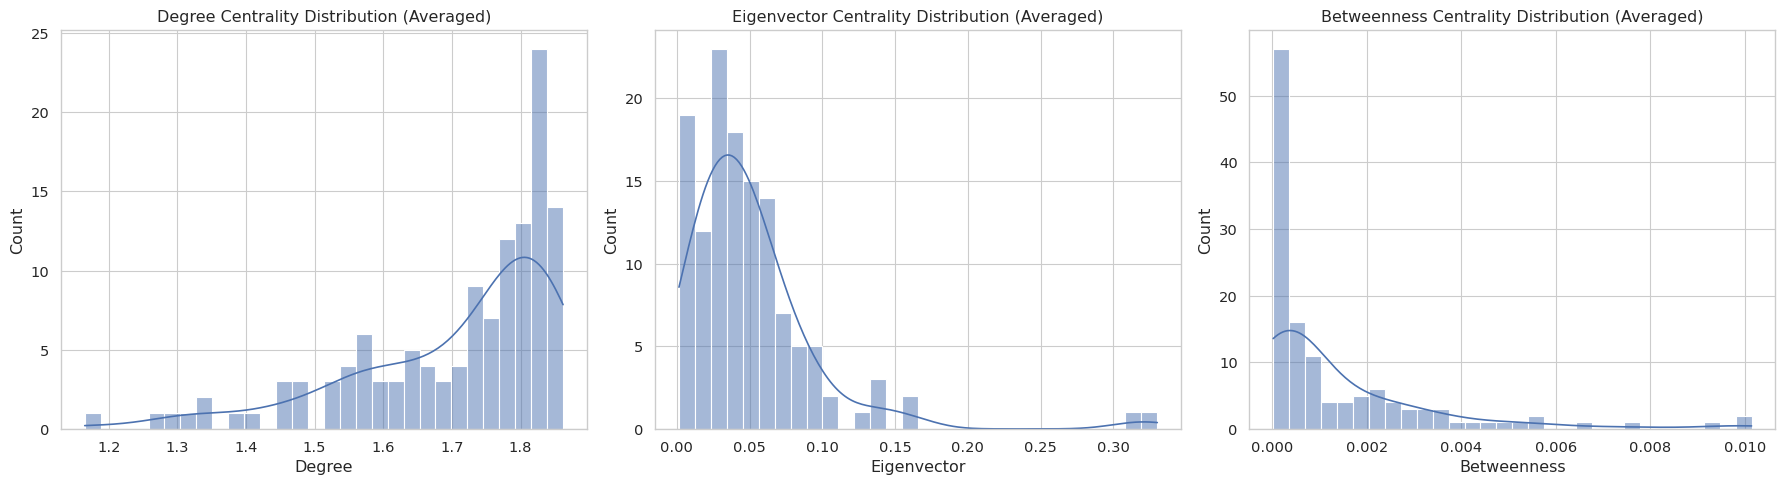

In [32]:
# Plotting Centrality Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(centrality_df.columns):
    sns.histplot(centrality_df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'{col} Centrality Distribution (Averaged)')
plt.tight_layout()
save_figure('centrality_distributions_averaged')
plt.show()

Figure saved to thesis_figures/SSE/centrality_ranking_stability.pdf


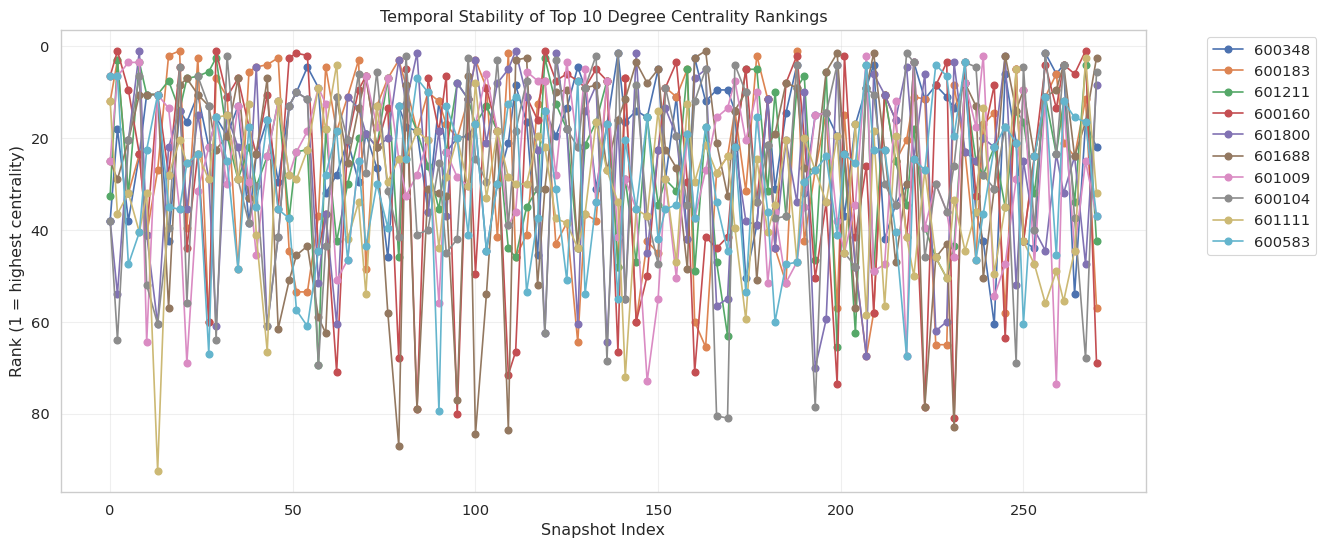

In [33]:
# Analyze temporal stability of centrality rankings
# For top 10 degree centrality nodes, track their ranking over time
top_10_nodes = centrality_df['Degree'].nlargest(10).index.tolist()
top_10_tickers = [train_analyzer.index_to_stock[i] for i in top_10_nodes]

degree_rankings_over_time = []
for idx in snapshot_indices:
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    deg_cent = pd.Series(nx.degree_centrality(G))
    rankings = {node: deg_cent.rank(ascending=False)[node] for node in top_10_nodes}
    degree_rankings_over_time.append(rankings)

ranking_df = pd.DataFrame(degree_rankings_over_time, index=snapshot_indices)
ranking_df.columns = top_10_tickers

plt.figure(figsize=(14, 6))
for ticker in ranking_df.columns:
    plt.plot(ranking_df.index, ranking_df[ticker], marker='o', label=ticker)
plt.gca().invert_yaxis()
plt.title('Temporal Stability of Top 10 Degree Centrality Rankings')
plt.xlabel('Snapshot Index')
plt.ylabel('Rank (1 = highest centrality)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
save_figure('centrality_ranking_stability')
plt.show()

---
## 4. Temporal Analysis of the Graph

### 4.1. Temporal Evolution of the Topology

Figure saved to thesis_figures/SSE/temporal_adj_stability.pdf


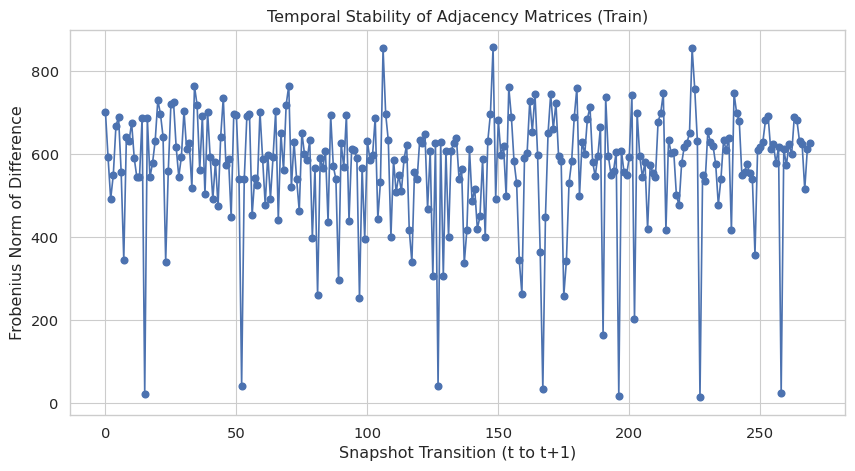

In [34]:
# Adjacency Matrix Stability
adj_diffs = []
for i in range(1, len(train_adjs)):
    diff = np.linalg.norm(train_adjs[i] - train_adjs[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices (Train)')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

Figure saved to thesis_figures/SSE/temporal_feature_trend.pdf


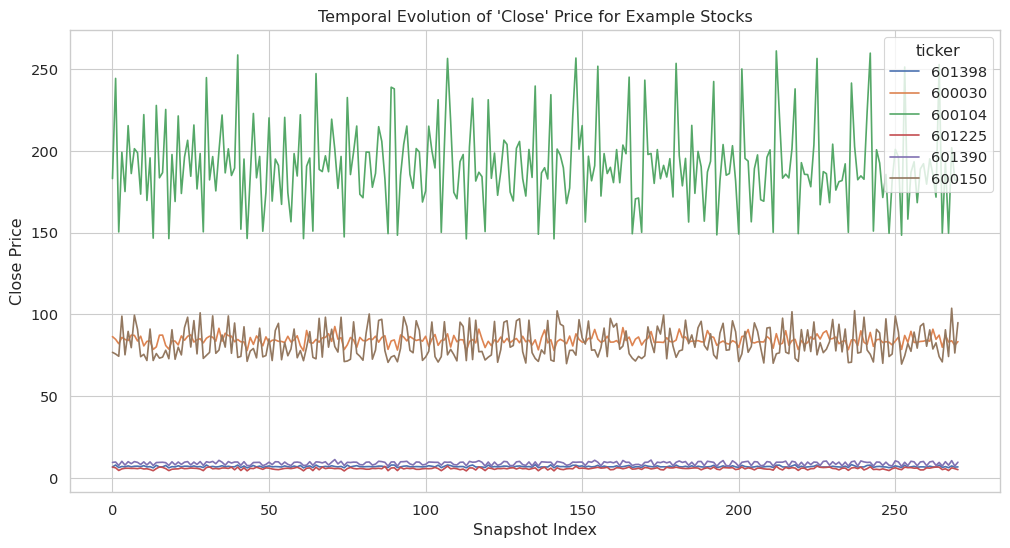

In [35]:
# Feature Evolution Over Time (example stocks)
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20, 30, 40, 50]]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
plt.title("Temporal Evolution of 'Close' Price for Example Stocks")
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
save_figure('temporal_feature_trend')
plt.show()

Figure saved to thesis_figures/SSE/temporal_graph_metrics.pdf


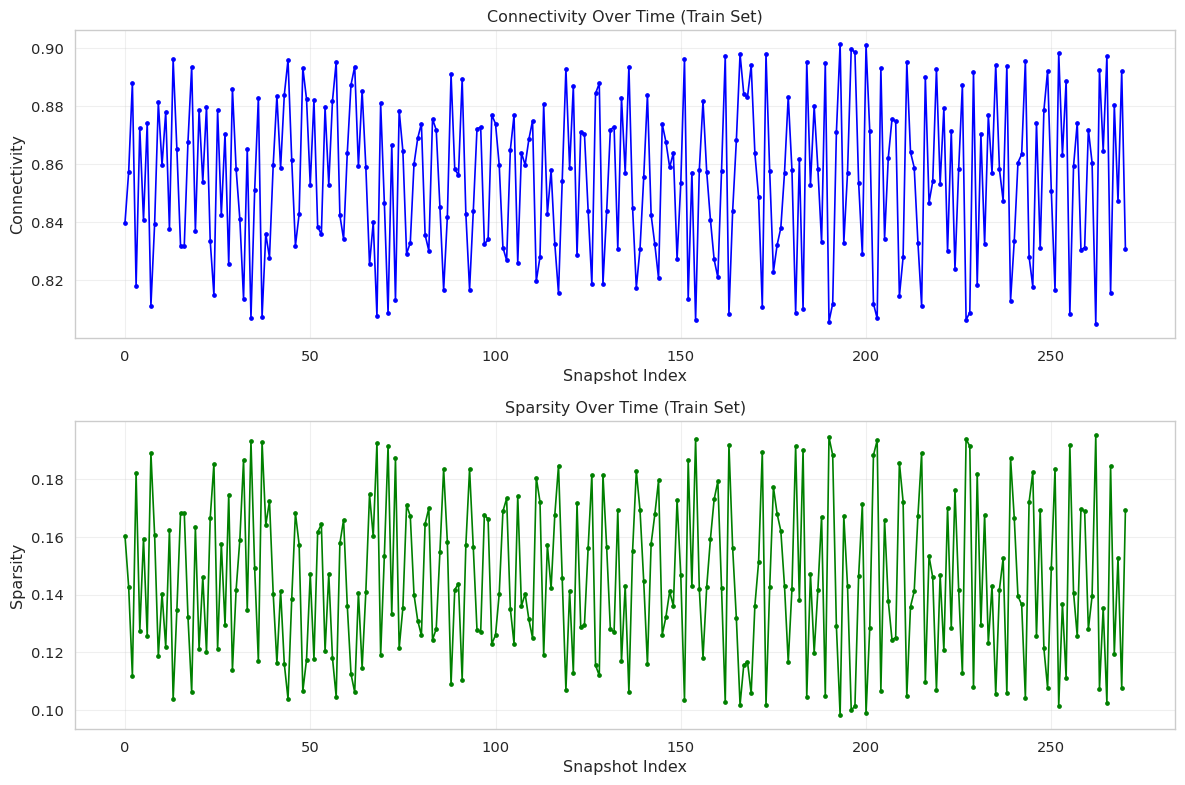

In [36]:
# Graph metrics evolution over time
connectivity_over_time = []
sparsity_over_time = []
for i in range(train_analyzer.num_snapshots):
    snapshot_info = train_analyzer.get_snapshot_info(i)
    connectivity_over_time.append(snapshot_info['connectivity'])
    num_nodes = snapshot_info['num_nodes']
    num_edges = snapshot_info['num_edges']
    possible_edges = num_nodes * (num_nodes - 1)
    sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
    sparsity_over_time.append(sparsity)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(connectivity_over_time, marker='.', linestyle='-', color='blue')
axes[0].set_title('Connectivity Over Time (Train Set)')
axes[0].set_xlabel('Snapshot Index')
axes[0].set_ylabel('Connectivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sparsity_over_time, marker='.', linestyle='-', color='green')
axes[1].set_title('Sparsity Over Time (Train Set)')
axes[1].set_xlabel('Snapshot Index')
axes[1].set_ylabel('Sparsity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure('temporal_graph_metrics')
plt.show()

Computing hyperbolicity across datasets...

Processing Train...


  Snapshot 270/271...
  Train complete: Mean δ = 1.1716

Processing Validation...
  Snapshot 110/112...
  Validation complete: Mean δ = 1.1964

Processing Test...
  Snapshot 470/474...
  Test complete: Mean δ = 1.1097

--- Hyperbolicity Summary (NASDAQ) ---


,split,avg_delta,std_delta,max_delta,min_delta
2,Test,1.109705,0.221690,2.0,1.0
0,Train,1.171587,0.248770,2.0,1.0
1,Validation,1.196429,0.301463,2.0,1.0



--- LaTeX Table: Hyperbolicity Summary ---
\begin{table}
\caption{Hyperbolicity summary for NASDAQ datasets.}
\label{tab:nasdaq_hyperbolicity}
\begin{tabular}{lrrrr}
\toprule
split & avg_delta & std_delta & max_delta & min_delta \\
\midrule
Test & 1.1097 & 0.2217 & 2.0000 & 1.0000 \\
Train & 1.1716 & 0.2488 & 2.0000 & 1.0000 \\
Validation & 1.1964 & 0.3015 & 2.0000 & 1.0000 \\
\bottomrule
\end{tabular}
\end{table}

Figure saved to thesis_figures/SSE/hyperbolicity_across_datasets.pdf


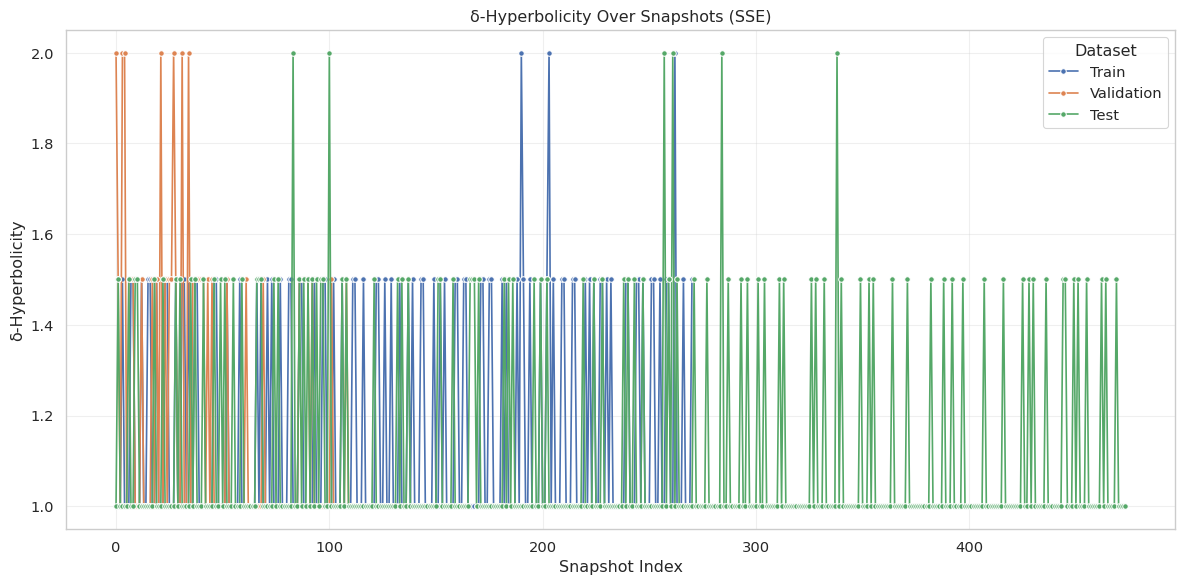

In [37]:
# Sample up to 500 quadruples per snapshot to keep runtime manageable.
SAMPLE_SIZE = 1000
RANDOM_STATE = 42
hyperbolicity_summary = []
hyperbolicity_by_snapshot = []

print("Computing hyperbolicity across datasets...")
for split_name, split_analyzer in analyzers.items():
    print(f"\nProcessing {split_name}...")
    snapshot_scores = []
    for idx in range(split_analyzer.num_snapshots):
        if idx % 10 == 0:
            print(f"  Snapshot {idx}/{split_analyzer.num_snapshots}...", end='\r')
        score = split_analyzer.compute_snapshot_hyperbolicity(idx, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
        snapshot_scores.append(score)
    
    print(f"\n  {split_name} complete: Mean δ = {np.mean(snapshot_scores):.4f}")
    
    if not snapshot_scores:
        continue
    hyperbolicity_summary.append({
        "split": split_name,
        "avg_delta": float(np.mean(snapshot_scores)),
        "std_delta": float(np.std(snapshot_scores)),
        "max_delta": float(np.max(snapshot_scores)),
        "min_delta": float(np.min(snapshot_scores))
    })
    hyperbolicity_by_snapshot.append(pd.DataFrame({
        "split": split_name,
        "snapshot_index": range(len(snapshot_scores)),
        "delta_hyperbolicity": snapshot_scores
    }))

hyperbolicity_summary_df = pd.DataFrame(hyperbolicity_summary).sort_values("avg_delta")
print("\n--- Hyperbolicity Summary (NASDAQ) ---")
display(hyperbolicity_summary_df)

# Save LaTeX table
print("\n--- LaTeX Table: Hyperbolicity Summary ---")
print(hyperbolicity_summary_df.to_latex(caption='Hyperbolicity summary for NASDAQ datasets.',
                                        label='tab:nasdaq_hyperbolicity',
                                        float_format="%.4f",
                                        index=False))

# Plot hyperbolicity over snapshots
hyperbolicity_by_snapshot_df = pd.concat(hyperbolicity_by_snapshot, ignore_index=True) if hyperbolicity_by_snapshot else pd.DataFrame()
if not hyperbolicity_by_snapshot_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=hyperbolicity_by_snapshot_df, x="snapshot_index", y="delta_hyperbolicity", 
                 hue="split", marker="o", markersize=4)
    plt.title("δ-Hyperbolicity Over Snapshots (SSE)")
    plt.ylabel("δ-Hyperbolicity")
    plt.xlabel("Snapshot Index")
    plt.legend(title='Dataset')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure('hyperbolicity_across_datasets')
    plt.show()
else:
    print("No hyperbolicity values were computed.")

---
## Analysis Complete

All figures have been saved to: `thesis_figures/SSE/`